# 2D Cusp WTMM Diagnostic

Generate 2D radial cusps with **known** Hölder exponent $H$, run the full WTMM pipeline,
and verify that the slope of $\log_2|W|$ vs $\log_2 a$ recovers $H$.

Test signals:
- **Radial cone**: $f(r) = r^H$ with $H = 0.3, 0.5, 0.7$
- **fBm** (xsmurf generator): monofractal with Hurst $H$

Two measurements:
1. **Direct**: max modulus near singularity at each scale (bypasses chains)
2. **WTMM chains**: full pipeline (extrema → hsearch → ssm → vchain → regression)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fftfreq
import mlx.core as mx
import sys
sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [10, 6]

## CWT + helper functions

In [ ]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]


def _build_wavelet_filters_f32(kx, ky, scale, wavelet='mexican'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)

    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)

    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx': to_complex(zero, sx * k2 * gauss),
            'dy': to_complex(zero, sy * k2 * gauss),
        }
    return {
        'dx': to_complex(zero, sx * gauss),
        'dy': to_complex(zero, sy * gauss),
    }


def cwt_2d_f32(image, scales, pad=32, wavelet='mexican'):
    """Minimal 2D CWT — returns dx, dy, mod, arg at each scale."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))

    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX = mx.array(KX_np)
    KY = mx.array(KY_np)

    image_fft = mx.fft.fft2(mx.array(padded))

    n = len(scales)
    result = {
        'dx': np.zeros((n, ny, nx), dtype=np.float32),
        'dy': np.zeros((n, ny, nx), dtype=np.float32),
        'mod': np.zeros((n, ny, nx), dtype=np.float32),
        'arg': np.zeros((n, ny, nx), dtype=np.float32),
    }

    for i, scale in enumerate(scales):
        filt = _build_wavelet_filters_f32(KX, KY, scale, wavelet)
        dx = np.array(mx.fft.ifft2(image_fft * filt['dx']).real)[crop]
        dy = np.array(mx.fft.ifft2(image_fft * filt['dy']).real)[crop]
        result['dx'][i] = dx
        result['dy'][i] = dy
        result['mod'][i] = np.sqrt(dx * dx + dy * dy)
        result['arg'][i] = np.arctan2(dy, dx).astype(np.float32)
    mx.eval()

    return result

print('CWT functions defined')

## Generate test signals

In [ ]:
def generate_fbm_2d(N, H=0.5, seed=42):
    """Spectral synthesis of 2D fractional Brownian motion."""
    rng = np.random.default_rng(seed)
    kx = np.fft.fftfreq(N)
    ky = np.fft.fftfreq(N)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0, 0] = 1.0  # avoid div by zero
    # Power spectrum P(k) ~ k^{-(2H+2)} for 2D fBm
    amplitude = K2 ** (-(H + 1) / 2.0)
    amplitude[0, 0] = 0.0  # zero mean
    noise = rng.standard_normal((N, N)) + 1j * rng.standard_normal((N, N))
    field = np.real(np.fft.ifft2(amplitude * noise))
    return (field / field.std()).astype(np.float32)


N = 512
cx, cy = N // 2, N // 2
yy, xx = np.mgrid[:N, :N]
r = np.sqrt((xx - cx).astype(np.float64)**2 + (yy - cy).astype(np.float64)**2)
r[cy, cx] = 1e-10  # avoid 0^H issues

H_values = [0.3, 0.5, 0.7]
test_signals = {}

# --- Radial cones: f(r) = r^H ---
for H in H_values:
    img = (r ** H).astype(np.float32)
    test_signals[f'cone H={H}'] = {'image': img, 'H': H, 'type': 'cone'}

# --- fBm (spectral synthesis, monofractal) ---
for H in H_values:
    fbm_img = generate_fbm_2d(N, H, seed=42)
    test_signals[f'fBm H={H}'] = {'image': fbm_img, 'H': H, 'type': 'fbm'}

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, H in enumerate(H_values):
    axes[0, i].imshow(test_signals[f'cone H={H}']['image'], cmap='gray')
    axes[0, i].set_title(f'Cone H={H}')
    axes[1, i].imshow(test_signals[f'fBm H={H}']['image'], cmap='gray')
    axes[1, i].set_title(f'fBm H={H}')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Direct modulus measurement (bypass chains)

For the **radial cone**, the modulus maxima form a ring around the center.  
At each scale, take the **max modulus near center** — this should scale as $a^H$.

For **fBm**, take the global mean modulus at each scale — should scale as $a^H$.

In [ ]:
n_oct, n_vox, a_min = 4, 8, 1
WAVELET = 'mexican'
scales = compute_scales(n_oct, n_vox, a_min)
log2_s = np.log2(scales)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for panel, stype in enumerate(['cone', 'fbm']):
    ax = axes[panel]
    for H in H_values:
        key = f'{stype.replace("fbm","fBm")} H={H}' if stype == 'fbm' else f'cone H={H}'
        sig = test_signals[key]
        cwt = cwt_2d_f32(sig['image'], scales, pad=32, wavelet=WAVELET)

        if stype == 'cone':
            # Max modulus in a window around center (ring of maxima)
            mod_vals = []
            for i, s in enumerate(scales):
                w = max(5, int(s * 0.8))
                w = min(w, cx - 2)
                patch = cwt['mod'][i][cy-w:cy+w, cx-w:cx+w]
                mod_vals.append(patch.max())
        else:
            # fBm: global mean modulus
            mod_vals = [cwt['mod'][i].mean() for i in range(len(scales))]

        log2_m = np.log2(np.maximum(mod_vals, 1e-30))

        # Regression on middle scale range (avoid boundary effects)
        n_s = len(scales)
        fit_slice = slice(n_s // 6, 5 * n_s // 6)
        A = np.vstack([log2_s[fit_slice], np.ones(len(log2_s[fit_slice]))]).T
        slope, intercept = np.linalg.lstsq(A, log2_m[fit_slice], rcond=None)[0]

        ax.plot(log2_s, log2_m, 'o-', ms=3, lw=1,
                label=f'H={H}, slope={slope:.3f}')
        ax.plot(log2_s[fit_slice],
                slope * log2_s[fit_slice] + intercept,
                'k--', lw=0.8, alpha=0.5)

    title = 'Cone: max |W| near center' if stype == 'cone' else 'fBm: mean |W|'
    ax.set(xlabel='log2(scale)', ylabel='log2(|W|)', title=f'Direct — {title}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Direct modulus scaling (wavelet={WAVELET})', fontsize=13)
plt.tight_layout()
plt.show()

## Full WTMM pipeline (chains)

In [ ]:
def run_wtmm_pipeline(image, n_oct, n_vox, a_min=1, wavelet='mexican',
                       thresh=1e-3, border_pct=1.5, pad=32):
    """Full WTMM pipeline: CWT -> extrema -> chain -> holders."""

    scales = compute_scales(n_oct, n_vox, a_min)
    cwt = cwt_2d_f32(image, scales, pad=pad, wavelet=wavelet)

    # --- WTMM extrema at each scale ---
    ext_images = []
    for i, scale in enumerate(scales):
        dx_xsm = xsm.XImage.from_numpy(cwt['dx'][i])
        dy_xsm = xsm.XImage.from_numpy(cwt['dy'][i])
        ext, _, _ = xsm.wtmm2d(dx_xsm, dy_xsm, scale, thresh=thresh)
        ext_images.append(ext)

    # --- Cut edges ---
    for i in range(len(ext_images)):
        ext_images[i] = xsm.cut_edge(ext_images[i], border_percent=border_pct)

    # --- Horizontal + vertical chaining ---
    xsm.chain(ext_images, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              smooth=False, verbose=False)

    # --- Extract chains + Holder exponents ---
    chains = xsm.extract_vertical_chains(ext_images, scales)
    holders = xsm.compute_holder_exponents(chains)

    return cwt, scales, ext_images, chains, holders

print('Pipeline function defined')

## Run on radial cones + fBm and show log-log plots

In [ ]:
n_oct, n_vox, a_min = 4, 8, 1
WAVELET = 'mexican'

results = {}
for name, sig in test_signals.items():
    print(f'\n=== {name} ===')
    cwt, scales, ext_images, chains, holders = run_wtmm_pipeline(
        sig['image'], n_oct, n_vox, a_min, wavelet=WAVELET)
    results[name] = {
        'cwt': cwt, 'scales': scales, 'ext_images': ext_images,
        'chains': chains, 'holders': holders,
        'H_true': sig['H'], 'type': sig['type'],
    }
    h_vals = [h['h'] for h in holders]
    print(f'  Chains: {len(chains)}, Holders: {len(holders)}')
    if h_vals:
        print(f'  h: median={np.median(h_vals):.3f}, '
              f'mean={np.mean(h_vals):.3f}, std={np.std(h_vals):.3f}')

In [ ]:
# ===== LOG-LOG DIAGNOSTIC PLOTS =====

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for col, H in enumerate(H_values):
    for row, stype in enumerate(['cone', 'fbm']):
        ax = axes[row, col]
        key = f'{stype.replace("fbm","fBm")} H={H}' if stype == 'fbm' else f'cone H={H}'
        res = results[key]
        chains = res['chains']
        log2_s = np.log2(res['scales'])

        # Build h lookup
        h_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in res['holders']}

        # Color by measured h
        h_all = [h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
                 for ch in chains]
        h_finite = [h for h in h_all if np.isfinite(h)]
        if not h_finite:
            ax.set_title(f'{key}: no chains')
            continue

        vmin, vmax = np.percentile(h_finite, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)

        # Plot chains (subsample if too many)
        max_plot = 2000
        plot_chains = chains[:max_plot]
        for ch in plot_chains:
            n = len(ch['mod'])
            if n < 3:
                continue
            anchor = (int(ch['x'][0]), int(ch['y'][0]))
            h = h_lookup.get(anchor, np.nan)
            if not np.isfinite(h):
                continue
            ax.plot(log2_s[:n], ch['log2_mod'],
                    '-', color=cm(nm(h)), alpha=0.3, lw=0.5)

        # Reference line: slope = H
        mid = len(log2_s) // 2
        ref_y0 = np.median([ch['log2_mod'][mid] for ch in chains
                            if len(ch['mod']) > mid])
        ref_line = H * (log2_s - log2_s[mid]) + ref_y0
        ax.plot(log2_s, ref_line, 'k--', lw=1.5, label=f'slope={H} (expected)')

        h_med = np.median(h_finite)
        ax.set_title(f'{key}\nmedian h = {h_med:.3f} (expect {H})')
        ax.set(xlabel='log2(scale)', ylabel='log2(|W|)')
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, alpha=0.3)

plt.suptitle('WTMM chains: log2|W| vs log2(scale)', fontsize=13)
plt.tight_layout()
plt.show()

## Holder histograms + cone spatial map

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, H in enumerate(H_values):
    for row, stype in enumerate(['cone', 'fbm']):
        ax = axes[row, col]
        key = f'{stype.replace("fbm","fBm")} H={H}' if stype == 'fbm' else f'cone H={H}'
        res = results[key]
        h_vals = [h['h'] for h in res['holders']]
        if not h_vals:
            continue

        ax.hist(h_vals, bins=60, range=(-1, 2), alpha=0.7, edgecolor='black', lw=0.3)
        ax.axvline(H, color='red', ls='--', lw=2, label=f'True H={H}')
        ax.axvline(np.median(h_vals), color='blue', ls='-', lw=1.5,
                   label=f'Median={np.median(h_vals):.3f}')
        ax.set(xlabel='h', ylabel='count', title=key)
        ax.legend(fontsize=8)

plt.suptitle('Holder exponent histograms', fontsize=13)
plt.tight_layout()
plt.show()

# --- Spatial map for cones: where are the chains near the center? ---
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for col, H in enumerate(H_values):
    ax = axes[col]
    res = results[f'cone H={H}']
    holders = res['holders']
    if not holders:
        continue
    xs = [h['x'] for h in holders]
    ys = [h['y'] for h in holders]
    hs = [h['h'] for h in holders]
    sc = ax.scatter(xs, ys, c=hs, cmap='coolwarm', s=1,
                    vmin=H-0.5, vmax=H+0.5)
    ax.plot(cx, cy, 'rx', ms=10, mew=2, label='singularity')
    ax.set_title(f'Cone H={H}: Holder map')
    ax.set_aspect('equal')
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, label='h')

plt.tight_layout()
plt.show()

## Summary table

In [ ]:
print(f'{"Signal":<16} {"H_true":>7} {"h_median":>9} {"h_mean":>9} {"h_std":>7} {"error":>7} {"n_chains":>9}')
print('-' * 75)

for name in sorted(results.keys()):
    res = results[name]
    h_vals = [h['h'] for h in res['holders']]
    H = res['H_true']
    if h_vals:
        med = np.median(h_vals)
        print(f'{name:<16} {H:>7.2f} {med:>9.3f} {np.mean(h_vals):>9.3f} '
              f'{np.std(h_vals):>7.3f} {med - H:>+7.3f} {len(h_vals):>9d}')
    else:
        print(f'{name:<16} {H:>7.2f} {"no chains":>9}')

print('\n--- Interpretation ---')
print('If h_median ≈ H_true: CWT scaling + chain pipeline is correct.')
print('If direct slope ≈ H but h_median ≠ H: issue in chaining, not CWT.')
print('If direct slope ≠ H: issue in CWT or wavelet definition.')

## 4-way method comparison on fBm

Run all combinations of extrema detection × smoothing on a single fBm (H=0.5):

| | no smooth | smooth |
|---|---|---|
| **wtmm2d** (NMS) | variant 1 | variant 2 |
| **follow** (kapa/kapap) | variant 3 | variant 4 |

In [ ]:
def cwt_2d_all_derivs(image, scales, pad=32):
    """2D CWT with all derivatives up to 3rd order (needed for follow method)."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))

    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    sx_base, sy_base = KX, KY  # will be scaled per-scale

    image_fft = mx.fft.fft2(mx.array(padded))

    names = ['dx','dy','dxx','dxy','dyy','dxxx','dxxy','dxyy','dyyy']
    n = len(scales)
    result = {k: np.zeros((n, ny, nx), dtype=np.float32) for k in names}
    result['mod'] = np.zeros((n, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n, ny, nx), dtype=np.float32)

    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)

    for i, scale in enumerate(scales):
        sx = KX * scale
        sy = KY * scale
        gauss = mx.exp(-(sx * sx + sy * sy))
        zero = mx.zeros_like(gauss)

        filts = {
            'dx':   to_complex(zero, sx * gauss),
            'dy':   to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sx * sy * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }
        for name in names:
            arr = np.array(mx.fft.ifft2(image_fft * filts[name]).real)[crop]
            result[name][i] = arr

        dx, dy = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx * dx + dy * dy)
        result['arg'][i] = np.arctan2(dy, dx).astype(np.float32)
    mx.eval()
    return result


def run_pipeline_variant(image, n_oct, n_vox, a_min=1, method='wtmm2d',
                         smooth=False, thresh=1e-3, border_pct=1.5, pad=32):
    """Run WTMM with configurable extrema method and smoothing."""
    scales = compute_scales(n_oct, n_vox, a_min)
    need_all = (method == 'follow')

    if need_all:
        cwt = cwt_2d_all_derivs(image, scales, pad=pad)
    else:
        cwt = cwt_2d_f32(image, scales, pad=pad)

    ext_images = []
    for i, scale in enumerate(scales):
        if method == 'follow':
            kapa = xsm.gkapa_numpy(cwt['dx'][i], cwt['dy'][i],
                                    cwt['dxx'][i], cwt['dxy'][i], cwt['dyy'][i])
            kapap = xsm.gkapap_numpy(cwt['dx'][i], cwt['dy'][i],
                                      cwt['dxx'][i], cwt['dxy'][i], cwt['dyy'][i],
                                      cwt['dxxx'][i], cwt['dxxy'][i],
                                      cwt['dxyy'][i], cwt['dyyy'][i])
            kapa_xsm = xsm.XImage.from_numpy(kapa)
            kapap_xsm = xsm.XImage.from_numpy(kapap)
            mod_xsm = xsm.XImage.from_numpy(cwt['mod'][i])
            arg_xsm = xsm.XImage.from_numpy(cwt['arg'][i])
            ext = xsm.find_extrema_follow(kapa_xsm, kapap_xsm,
                                           mod_xsm, arg_xsm, scale, thresh)
        else:
            dx_xsm = xsm.XImage.from_numpy(cwt['dx'][i])
            dy_xsm = xsm.XImage.from_numpy(cwt['dy'][i])
            ext, _, _ = xsm.wtmm2d(dx_xsm, dy_xsm, scale, thresh=thresh)
        ext_images.append(ext)

    for i in range(len(ext_images)):
        ext_images[i] = xsm.cut_edge(ext_images[i], border_percent=border_pct)

    xsm.chain(ext_images, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              smooth=smooth, verbose=False)

    chains = xsm.extract_vertical_chains(ext_images, scales)
    holders = xsm.compute_holder_exponents(chains)
    return scales, chains, holders

print('4-way pipeline defined')

In [ ]:
H_test = 0.5
n_oct, n_vox, a_min = 4, 8, 1
fbm_image = generate_fbm_2d(512, H_test, seed=42)

variants = [
    ('wtmm2d',  False, 'NMS, no smooth'),
    ('wtmm2d',  True,  'NMS, smooth'),
    ('follow',  False, 'follow, no smooth'),
    ('follow',  True,  'follow, smooth'),
]

variant_results = {}
for method, smooth, label in variants:
    print(f'\n--- {label} ---')
    scales, chains, holders = run_pipeline_variant(
        fbm_image, n_oct, n_vox, a_min,
        method=method, smooth=smooth)
    h_vals = [h['h'] for h in holders]
    variant_results[label] = {
        'scales': scales, 'chains': chains, 'holders': holders,
    }
    print(f'  Chains: {len(chains)}, Holders: {len(holders)}')
    if h_vals:
        print(f'  h: median={np.median(h_vals):.3f}, '
              f'mean={np.mean(h_vals):.3f}, std={np.std(h_vals):.3f}')

print('\nDone.')

In [ ]:
# ===== 2x2 LOG-LOG COMPARISON =====

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
log2_s = np.log2(scales)

for idx, (method, smooth, label) in enumerate(variants):
    ax = axes[idx // 2, idx % 2]
    res = variant_results[label]
    chains = res['chains']
    holders = res['holders']

    h_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders}
    h_finite = [h['h'] for h in holders if np.isfinite(h['h'])]

    if not h_finite:
        ax.set_title(f'{label}: no chains')
        continue

    vmin, vmax = np.percentile(h_finite, [5, 95])
    cm = plt.cm.coolwarm
    nm = plt.Normalize(vmin, vmax)

    for ch in chains[:2000]:
        n = len(ch['mod'])
        if n < 3:
            continue
        anchor = (int(ch['x'][0]), int(ch['y'][0]))
        h = h_lookup.get(anchor, np.nan)
        if not np.isfinite(h):
            continue
        ax.plot(log2_s[:n], ch['log2_mod'],
                '-', color=cm(nm(h)), alpha=0.25, lw=0.5)

    # Reference line: slope = H_test
    mid = len(log2_s) // 2
    mods_at_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
    if mods_at_mid:
        ref_y0 = np.median(mods_at_mid)
        ref_line = H_test * (log2_s - log2_s[mid]) + ref_y0
        ax.plot(log2_s, ref_line, 'k--', lw=2, label=f'slope={H_test} (expected)')

    h_med = np.median(h_finite)
    ax.set_title(f'{label}\nmedian h = {h_med:.3f}  (expect {H_test})\n'
                 f'{len(chains)} chains, {len(holders)} holders')
    ax.set(xlabel='log2(scale)', ylabel='log2(|W|)')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'fBm H={H_test}: method comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ===== HISTOGRAM COMPARISON: OLS vs MAX SLOPE =====

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for idx, (method, smooth, label) in enumerate(variants):
    res = variant_results[label]
    chains = res['chains']

    # OLS (global least-squares fit)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    # Max local slope (xsmurf pf::localslope style)
    h_max = [h['h'] for h in xsm.compute_holder_local_slope(chains, method='max')]

    for row, (h_vals, h_label) in enumerate([(h_ols, 'OLS fit'), (h_max, 'max slope')]):
        ax = axes[row, idx]
        if not h_vals:
            ax.set_title(f'{label}\n{h_label}: no data')
            continue
        ax.hist(h_vals, bins=50, range=(-0.5, 1.5), alpha=0.7,
                edgecolor='black', lw=0.3)
        ax.axvline(H_test, color='red', ls='--', lw=2, label=f'H={H_test}')
        med = np.median(h_vals)
        ax.axvline(med, color='blue', lw=1.5, label=f'med={med:.3f}')
        ax.set(xlabel='h', ylabel='count')
        ax.set_title(f'{label}\n{h_label}')
        ax.legend(fontsize=7)

axes[0, 0].set_ylabel('OLS fit\ncount')
axes[1, 0].set_ylabel('max slope\ncount')
plt.suptitle(f'fBm H={H_test}: OLS fit vs max local slope', fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Method":<22} {"h_type":<10} {"median":>8} {"mean":>8} {"std":>7} {"error":>7} {"count":>6}')
print('-' * 75)
for method, smooth, label in variants:
    res = variant_results[label]
    chains = res['chains']
    for h_type, func in [('OLS', xsm.compute_holder_exponents),
                          ('max_slope', lambda c: xsm.compute_holder_local_slope(c, method='max'))]:
        h_vals = [h['h'] for h in func(chains)]
        if h_vals:
            med = np.median(h_vals)
            print(f'{label:<22} {h_type:<10} {med:>8.3f} {np.mean(h_vals):>8.3f} '
                  f'{np.std(h_vals):>7.3f} {med - H_test:>+7.3f} {len(h_vals):>6d}')

## 4-way comparison using xsmurf native CWT (gfft + libmatheval)

Same 4 variants, but CWT is done entirely in xsmurf C code via `iwtmm`.
This is the ground truth — if results differ from the Python CWT cells above,
the Python CWT has a bug.

In [ ]:
def run_pipeline_xsmurf(image, n_oct, n_vox, a_min=1, method='wtmm2d',
                         smooth=False, thresh=1e-3, border_pct=1.5,
                         wavelet='mexican'):
    """Full WTMM using xsmurf native CWT (gfft + libmatheval).

    wavelet: 'gaussian' uses x*exp(-x*x-y*y)  (1 vanishing moment)
             'mexican'  uses x*(x*x+y*y)*exp(-x*x-y*y)  (3 vanishing moments)
    """
    # Mexican hat derivative expressions (gradient of Laplacian of Gaussian)
    MEXICAN_EXPRS = {
        'dx':   ('0',                              'x*(x*x+y*y)*exp(-x*x-y*y)'),
        'dy':   ('0',                              'y*(x*x+y*y)*exp(-x*x-y*y)'),
        'dxx':  ('-(x*x)*(x*x+y*y)*exp(-x*x-y*y)', '0'),
        'dxy':  ('-(x*y)*(x*x+y*y)*exp(-x*x-y*y)', '0'),
        'dyy':  ('-(y*y)*(x*x+y*y)*exp(-x*x-y*y)', '0'),
        'dxxx': ('0', '-(x*x*x)*(x*x+y*y)*exp(-x*x-y*y)'),
        'dxxy': ('0', '-(x*x*y)*(x*x+y*y)*exp(-x*x-y*y)'),
        'dxyy': ('0', '-(x*y*y)*(x*x+y*y)*exp(-x*x-y*y)'),
        'dyyy': ('0', '-(y*y*y)*(x*x+y*y)*exp(-x*x-y*y)'),
    }

    if wavelet == 'gaussian':
        # Use iwtmm which hardcodes Gaussian expressions
        wt = xsm.iwtmm(image, a_min, n_oct, n_vox,
                        method=method, thresh=thresh, verbose=False)
        ext_images = wt['ext_images']
        scales = wt['scales']
    else:
        # Mexican hat: manual CWT via iconvol with custom expressions
        from xsmurf_wrapper.wavelet import compute_scales as xsm_compute_scales
        ximg = xsm.XImage.from_numpy(np.ascontiguousarray(image, dtype=np.float32))
        fft_img = xsm.igfft(ximg)
        scales_info = xsm_compute_scales(a_min, n_oct, n_vox)
        EXPRS = MEXICAN_EXPRS

        ext_images = []
        scales = []
        for sid, o, v, scale in scales_info:
            dx = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dx'], scale))
            dy = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dy'], scale))

            if method == 'follow':
                mod_img = xsm.gmod(dx, dy)
                arg_img = xsm.garg(dx, dy)
                dxx = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dxx'], scale))
                dxy = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dxy'], scale))
                dyy = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dyy'], scale))
                dxxx = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dxxx'], scale))
                dxxy = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dxxy'], scale))
                dxyy = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dxyy'], scale))
                dyyy = xsm.igifft(xsm.iconvol(fft_img, *EXPRS['dyyy'], scale))
                kapa_img = xsm.gkapa(dx, dy, dxx, dxy, dyy)
                kapap_img = xsm.gkapap(dx, dy, dxx, dxy, dyy, dxxx, dxxy, dxyy, dyyy)
                ext = xsm.find_extrema_follow(kapa_img, kapap_img,
                                               mod_img, arg_img, scale, thresh)
            else:
                ext, _, _ = xsm.wtmm2d(dx, dy, scale, thresh=thresh)
            ext_images.append(ext)
            scales.append(scale)

    for i in range(len(ext_images)):
        ext_images[i] = xsm.cut_edge(ext_images[i], border_percent=border_pct)

    xsm.chain(ext_images, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              smooth=smooth, verbose=False)

    chains = xsm.extract_vertical_chains(ext_images, scales)
    holders = xsm.compute_holder_exponents(chains)
    return scales, chains, holders

print('xsmurf pipeline defined (supports gaussian + mexican)')

In [ ]:
# ===== SIDE-BY-SIDE: Python CWT vs xsmurf CWT =====

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

for idx, (method, smooth, label) in enumerate(variants):
    for row, (src, res_dict) in enumerate([('Python CWT', variant_results),
                                            ('xsmurf CWT', xsm_results)]):
        ax = axes[row, idx]
        res = res_dict[label]
        chains = res['chains']
        holders = res['holders']
        log2_s = np.log2(res['scales'])

        h_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders}
        h_finite = [h['h'] for h in holders if np.isfinite(h['h'])]

        if not h_finite:
            ax.set_title(f'{src}\n{label}: no chains')
            continue

        vmin, vmax = np.percentile(h_finite, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)

        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3:
                continue
            anchor = (int(ch['x'][0]), int(ch['y'][0]))
            h = h_lookup.get(anchor, np.nan)
            if not np.isfinite(h):
                continue
            ax.plot(log2_s[:n], ch['log2_mod'],
                    '-', color=cm(nm(h)), alpha=0.2, lw=0.5)

        mid = len(log2_s) // 2
        mods_at_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
        if mods_at_mid:
            ref_y0 = np.median(mods_at_mid)
            ref_line = H_test * (log2_s - log2_s[mid]) + ref_y0
            ax.plot(log2_s, ref_line, 'k--', lw=2, label=f'slope={H_test}')

        h_med = np.median(h_finite)
        ax.set_title(f'{src} — {label}\nmed h={h_med:.3f} ({len(chains)} chains)')
        ax.set(xlabel='log2(a)', ylabel='log2|W|')
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)

plt.suptitle(f'fBm H={H_test}: Python CWT (top) vs xsmurf native CWT (bottom)',
             fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ===== COMBINED SUMMARY: Python vs xsmurf, OLS vs max-slope =====

print(f'{"CWT":<8} {"Pipeline":<22} {"h_type":<10} {"median":>8} {"mean":>8} {"std":>7} {"error":>7} {"chains":>7}')
print('-' * 82)
for cwt_label, res_dict in [('Python', variant_results), ('xsmurf', xsm_results)]:
    for method, smooth, label in variants:
        chains = res_dict[label]['chains']
        for h_type, func in [('OLS', xsm.compute_holder_exponents),
                              ('max_slp', lambda c: xsm.compute_holder_local_slope(c, method='max'))]:
            h_vals = [h['h'] for h in func(chains)]
            if h_vals:
                med = np.median(h_vals)
                print(f'{cwt_label:<8} {label:<22} {h_type:<10} {med:>8.3f} '
                      f'{np.mean(h_vals):>8.3f} {np.std(h_vals):>7.3f} '
                      f'{med - H_test:>+7.3f} {len(h_vals):>7d}')
    print()

## Interactive partition function viewer

Switch between all 8 realizations (4 Python CWT + 4 xsmurf CWT).
Shows $\log_2 Z(q,a)$ vs $\log_2 a$, $\tau(q)$, $D(h)$, and chain log-log overlay.

In [ ]:
# Compute BOTH standard and chainmax partition functions for all 8 realizations
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

q_list_full = np.concatenate([
    np.arange(-5, -2, 0.5), np.arange(-2, 2.01, 0.25), np.arange(2.5, 5.5, 0.5)])
n_q = len(q_list_full)
log2 = np.log(2.0)

def build_hd_from_chains(chains, scales_list):
    """Build per-scale tau/h/D arrays for standard and chainmax from chains."""
    n_sc = len(scales_list)
    STq_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STq_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    Nq = np.zeros(n_sc, dtype=np.int64)

    for ch in chains:
        n_ch = len(ch['mod'])
        running_max = 0.0
        for si in range(min(n_ch, n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0: continue
            if m > running_max:
                running_max = m
            log_m = np.log(m)
            log_m_sup = np.log(max(running_max, 1e-30))
            Nq[si] += 1
            for qi, q in enumerate(q_list_full):
                mq = m ** q if q != 0 else 1.0
                STq_std[qi, si] += mq
                STqlogT_std[qi, si] += log_m * mq
                mq_sup = running_max ** q if q != 0 else 1.0
                STq_cmax[qi, si] += mq_sup
                STqlogT_cmax[qi, si] += log_m_sup * mq_sup

    def _build(STq, STqlogT):
        tau = np.full((n_q, n_sc), np.nan)
        h = np.full((n_q, n_sc), np.nan)
        D = np.full((n_q, n_sc), np.nan)
        vZ = STq > 0
        tau[vZ] = np.log(STq[vZ]) / log2
        h[vZ] = STqlogT[vZ] / (log2 * STq[vZ])
        for qi, q in enumerate(q_list_full):
            for si in range(n_sc):
                if STq[qi, si] > 0:
                    D[qi, si] = (q * STqlogT[qi, si]
                                 - STq[qi, si] * np.log(STq[qi, si])) / (STq[qi, si] * log2)
        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
                'q_list': q_list_full,
                'scales': np.array(scales_list),
                'log2_scales': np.log2(np.array(scales_list))}

    return _build(STq_std, STqlogT_std), _build(STq_cmax, STqlogT_cmax), Nq


all_viewers = {}  # key -> {'hd_std', 'hd_cmax', 'chains', 'scales'}

for cwt_label, res_dict in [('Python', variant_results), ('xsmurf', xsm_results)]:
    for method, smooth, pipe_label in variants:
        key = f'{cwt_label} | {pipe_label}'
        res = res_dict[pipe_label]
        print(f'Building PF: {key} ({len(res["chains"])} chains) ...')

        # Re-run pipeline to get ext_images for chain info
        if cwt_label == 'Python':
            sc, ch, ho = run_pipeline_variant(
                fbm_image, n_oct, n_vox, a_min,
                method=method, smooth=smooth)
        else:
            sc, ch, ho = run_pipeline_xsmurf(
                fbm_image, n_oct, n_vox, a_min,
                method=method, smooth=smooth, wavelet='mexican')

        hd_std, hd_cmax, Nq = build_hd_from_chains(ch, sc)
        all_viewers[key] = {
            'hd_std': hd_std, 'hd_cmax': hd_cmax,
            'chains': ch, 'scales': sc, 'Nq': Nq,
        }

viewer_keys = list(all_viewers.keys())
print(f'\nDone. {len(viewer_keys)} realizations ready.')

In [ ]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

fit_state = {'scale_min': None, 'scale_max': None}

realization_dd = widgets.Dropdown(
    options=viewer_keys, value=viewer_keys[0],
    description='Realization:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='420px'))

chainmax_toggle = widgets.ToggleButtons(
    options=['Standard (-vc)', 'Chainmax (-vc_max)'],
    value='Standard (-vc)', description='PF mode:')

q_show = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

def get_current():
    v = all_viewers[realization_dd.value]
    hd = v['hd_std'] if 'Standard' in chainmax_toggle.value else v['hd_cmax']
    return v, hd

_fig_pf, _axes_pf = plt.subplots(2, 3, figsize=(14, 7),
                                  gridspec_kw={'height_ratios': [1, 1]})
_axes_top = _axes_pf[0]
_ax_tau_h = _axes_pf[1, 0]
_ax_dh = _axes_pf[1, 1]
_ax_hist = _axes_pf[1, 2]

# Track twin axis so we can remove it on redraw
_twin_ax = [None]

def _on_click_pf(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_top: return
    a = 2 ** event.xdata
    if event.button == 1: fit_state['scale_min'] = a
    elif event.button == 3: fit_state['scale_max'] = a
    if (fit_state['scale_min'] is not None and fit_state['scale_max'] is not None
            and fit_state['scale_min'] > fit_state['scale_max']):
        fit_state['scale_min'], fit_state['scale_max'] = (
            fit_state['scale_max'], fit_state['scale_min'])
    draw_all()

_fig_pf.canvas.mpl_connect('button_press_event', _on_click_pf)

def draw_all(*_):
    v, hd = get_current()
    scales_arr = np.array(v['scales'])
    log2_s = hd['log2_scales']
    chains = v['chains']
    method = chainmax_toggle.value
    n_sc = len(scales_arr)

    # Default fit range if not set
    if fit_state['scale_min'] is None:
        fit_state['scale_min'] = scales_arr[2]
    if fit_state['scale_max'] is None:
        fit_state['scale_max'] = scales_arr[-3]
    smin, smax = fit_state['scale_min'], fit_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    # --- Top row: tau(q,a), h(q,a), D(q,a) vs log2(a) ---
    for ax in _axes_top:
        ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_top[panel]
        for qi_val, color in zip(q_show, colors_q):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]; valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    xl = log2_s[valid]
                    ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(xl[-1]+0.05, sl*xl[-1]+ic,
                            f'{hd["q_list"][idx]:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    _axes_top[1].set_title(
        f'{method}  L-click=min R-click=max  [{smin:.1f}, {smax:.1f}]', fontsize=9)

    # --- Bottom-left: tau(q) + h(q) twin ---
    _ax_tau_h.cla()
    if _twin_ax[0] is not None:
        _twin_ax[0].remove()
        _twin_ax[0] = None

    _ax_dh.cla()
    _ax_hist.cla()

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

        if valid.any():
            _ax_tau_h.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
            _ax_tau_h.plot(q, q * H_test - 2, 'b--', alpha=0.4, label=f'qH-2 (theory)')
            _ax_tau_h.set(xlabel='q', ylabel='tau(q)')
            _ax_tau_h.tick_params(axis='y', labelcolor='steelblue')
            _ax_tau_h.grid(True, alpha=0.2)

            ax2 = _ax_tau_h.twinx()
            _twin_ax[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.axhline(H_test, color='red', ls='--', alpha=0.4)
            ax2.set(ylabel='h(q)')
            ax2.tick_params(axis='y', labelcolor='red')
            h_w = res['h'][valid].max() - res['h'][valid].min()
            _ax_tau_h.set_title(f'tau(q) & h(q)  dh={h_w:.3f}', fontsize=9)
            l1, lb1 = _ax_tau_h.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_tau_h.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)

            # --- Bottom-middle: D(h) ---
            sc = _ax_dh.scatter(res['h'][valid], res['D'][valid],
                                c=q[valid], cmap='coolwarm',
                                s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
            pk = np.argmax(res['D'][valid])
            _ax_dh.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
            _ax_dh.annotate(
                f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                xy=(res['h'][valid][pk], res['D'][valid][pk]),
                xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                bbox=dict(boxstyle='round', fc='lightyellow'))
            _ax_dh.set(xlabel='h', ylabel='D(h)', title=f'D(h) [{method}]',
                       xlim=(-1.1, 1.1), ylim=(0, 2.2))
            _ax_dh.legend(fontsize=7)
            _ax_dh.grid(True, alpha=0.2)

    # --- Bottom-right: h histogram (OLS + max slope) ---
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_max = [h['h'] for h in xsm.compute_holder_local_slope(chains, method='max')]
    if h_ols:
        _ax_hist.hist(h_ols, bins=50, range=(-0.5, 1.5), alpha=0.5,
                      label=f'OLS med={np.median(h_ols):.3f}', color='steelblue')
    if h_max:
        _ax_hist.hist(h_max, bins=50, range=(-0.5, 1.5), alpha=0.5,
                      label=f'max med={np.median(h_max):.3f}', color='orange')
    _ax_hist.axvline(H_test, color='red', ls='--', lw=2)
    _ax_hist.set(xlabel='h', ylabel='count', title='Holder histograms')
    _ax_hist.legend(fontsize=7)

    _fig_pf.suptitle(realization_dd.value, fontsize=12)
    _fig_pf.canvas.draw_idle()

realization_dd.observe(draw_all, names='value')
chainmax_toggle.observe(draw_all, names='value')

print('LEFT-click = set min scale | RIGHT-click = set max scale')
display(widgets.HBox([realization_dd, chainmax_toggle]))
draw_all()

## Padding investigation

xsmurf's gfft path does **no padding** for power-of-2 images (zero-pads to next power of 2 otherwise).  
Our Python CWT adds 32px **reflect** padding by default.

Test: run the Python WTMM pipeline with different padding modes and compare h distributions.

| pad | mode | effective size | matches xsmurf? |
|-----|------|----------------|------------------|
| 0 | none | 512×512 | yes (for power-of-2) |
| 32 | reflect | 576×576 | no |
| 32 | constant(0) | 576×576 | closer (zero-pad) |
| 64 | reflect | 640×640 | no |

In [ ]:
def cwt_2d_padmode(image, scales, pad=32, pad_mode='reflect', wavelet='mexican'):
    """2D CWT with configurable padding mode."""
    ny, nx = image.shape
    if pad > 0:
        if pad_mode == 'constant':
            padded = np.pad(image, pad, mode='constant', constant_values=0).astype(np.float32)
        else:
            padded = np.pad(image, pad, mode=pad_mode).astype(np.float32)
    else:
        padded = image.astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx)) if pad > 0 else (slice(None), slice(None))

    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)

    image_fft = mx.fft.fft2(mx.array(padded))

    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)

    n = len(scales)
    result = {
        'dx': np.zeros((n, ny, nx), dtype=np.float32),
        'dy': np.zeros((n, ny, nx), dtype=np.float32),
        'mod': np.zeros((n, ny, nx), dtype=np.float32),
        'arg': np.zeros((n, ny, nx), dtype=np.float32),
    }

    for i, scale in enumerate(scales):
        sx = KX * scale
        sy = KY * scale
        gauss = mx.exp(-(sx * sx + sy * sy))
        zero = mx.zeros_like(gauss)
        if wavelet == 'mexican':
            k2 = sx * sx + sy * sy
            filt_dx = to_complex(zero, sx * k2 * gauss)
            filt_dy = to_complex(zero, sy * k2 * gauss)
        else:
            filt_dx = to_complex(zero, sx * gauss)
            filt_dy = to_complex(zero, sy * gauss)
        dx = np.array(mx.fft.ifft2(image_fft * filt_dx).real)[crop]
        dy = np.array(mx.fft.ifft2(image_fft * filt_dy).real)[crop]
        result['dx'][i] = dx
        result['dy'][i] = dy
        result['mod'][i] = np.sqrt(dx * dx + dy * dy)
        result['arg'][i] = np.arctan2(dy, dx).astype(np.float32)
    mx.eval()
    return result


pad_variants = [
    (0,  'reflect',  'pad=0 (no pad, like xsmurf)'),
    (32, 'reflect',  'pad=32, reflect'),
    (32, 'constant', 'pad=32, zero'),
    (64, 'reflect',  'pad=64, reflect'),
]

pad_results = {}
for pad_size, pad_mode, label in pad_variants:
    print(f'--- {label} ---')
    sc = compute_scales(n_oct, n_vox, a_min)
    cwt = cwt_2d_padmode(fbm_image, sc, pad=pad_size, pad_mode=pad_mode)

    ext_images = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_images.append(ext)
    for i in range(len(ext_images)):
        ext_images[i] = xsm.cut_edge(ext_images[i], border_percent=1.5)
    xsm.chain(ext_images, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              smooth=False, verbose=False)
    chains = xsm.extract_vertical_chains(ext_images, sc)
    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders]

    pad_results[label] = {'chains': chains, 'holders': holders, 'scales': sc}
    if h_vals:
        print(f'  chains={len(chains)}, med h={np.median(h_vals):.3f}, '
              f'mean={np.mean(h_vals):.3f}, std={np.std(h_vals):.3f}')

print('\nDone.')

In [ ]:
# ===== PADDING COMPARISON: histograms + log-log + summary =====

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
log2_s = np.log2(compute_scales(n_oct, n_vox, a_min))

for idx, (pad_size, pad_mode, label) in enumerate(pad_variants):
    res = pad_results[label]
    chains = res['chains']
    holders = res['holders']
    h_vals = [h['h'] for h in holders]
    h_lookup = {(int(h['x']), int(h['y'])): h['h'] for h in holders}

    # Top: log-log chains
    ax = axes[0, idx]
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(log2_s[:n], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            ref = H_test * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2)
    ax.set(xlabel='log2(a)', ylabel='log2|W|',
           title=f'{label}\n{len(chains)} chains')
    ax.grid(True, alpha=0.3)

    # Bottom: histograms (OLS + max slope)
    ax = axes[1, idx]
    h_max = [h['h'] for h in xsm.compute_holder_local_slope(chains, method='max')]
    if h_vals:
        ax.hist(h_vals, bins=50, range=(-0.5, 1.5), alpha=0.5,
                label=f'OLS med={np.median(h_vals):.3f}', color='steelblue')
    if h_max:
        ax.hist(h_max, bins=50, range=(-0.5, 1.5), alpha=0.5,
                label=f'max med={np.median(h_max):.3f}', color='orange')
    ax.axvline(H_test, color='red', ls='--', lw=2)
    ax.set(xlabel='h', ylabel='count', title=label)
    ax.legend(fontsize=7)

plt.suptitle(f'fBm H={H_test}: padding comparison (NMS, no smooth, mexican)',
             fontsize=13)
plt.tight_layout()
plt.show()

# Summary
print(f'{"Padding":<28} {"h_type":<10} {"median":>8} {"mean":>8} {"std":>7} {"error":>7} {"chains":>7}')
print('-' * 80)
for pad_size, pad_mode, label in pad_variants:
    res = pad_results[label]
    chains = res['chains']
    for h_type, func in [('OLS', xsm.compute_holder_exponents),
                          ('max_slp', lambda c: xsm.compute_holder_local_slope(c, method='max'))]:
        h_vals = [h['h'] for h in func(chains)]
        if h_vals:
            med = np.median(h_vals)
            print(f'{label:<28} {h_type:<10} {med:>8.3f} {np.mean(h_vals):>8.3f} '
                  f'{np.std(h_vals):>7.3f} {med - H_test:>+7.3f} {len(h_vals):>7d}')

## gfft vs FFTW vs Python CWT: side-by-side wavelet coefficients

Three backends for the same CWT:
1. **gfft** — xsmurf's custom FFT + libmatheval (power-of-2 only)
2. **FFTW** — xsmurf's FFTW3 path + hardcoded filters (arbitrary sizes)
3. **Python** — MLX fft2 + numpy (our code, with/without padding)

Note: FFTW `fftw_convolve` has an **x↔y swap** vs gfft (core.pyx line 972).

In [ ]:
# Compare gfft vs FFTW vs Python at 3 scales

test_img = fbm_image  # 512x512
test_scales_idx = [0, 15, 31]  # small, mid, large from our scale array
test_scales = [compute_scales(n_oct, n_vox, a_min)[i] for i in test_scales_idx]

print(f'Image: {test_img.shape}')
print(f'Test scales: {[f"{s:.2f}" for s in test_scales]}')
print(f'log2(scales): {[f"{np.log2(s):.2f}" for s in test_scales]}')
print()

# --- gfft path ---
ximg = xsm.XImage.from_numpy(test_img)
fft_gfft = xsm.igfft(ximg)
gfft_mod = {}
for s in test_scales:
    dx = xsm.igifft(xsm.iconvol(fft_gfft, '0', 'x*exp(-x*x-y*y)', s))
    dy = xsm.igifft(xsm.iconvol(fft_gfft, '0', 'y*exp(-x*x-y*y)', s))
    mod = xsm.gmod(dx, dy)
    gfft_mod[s] = mod.to_numpy()
print('gfft: done')

# --- FFTW path ---
fft_fftw = xsm.ifftw(ximg)
fftw_mod = {}
for s in test_scales:
    fft_dx = fft_fftw.duplicate()
    xsm.fftw_convolve(fft_dx, 'dx', s)
    dx = xsm.ifftw_inverse(fft_dx)
    fft_dy = fft_fftw.duplicate()
    xsm.fftw_convolve(fft_dy, 'dy', s)
    dy = xsm.ifftw_inverse(fft_dy)
    mod = xsm.gmod(dx, dy)
    fftw_mod[s] = mod.to_numpy()
print('FFTW: done')

# --- Python (pad=0, to match xsmurf) ---
all_scales = compute_scales(n_oct, n_vox, a_min)
cwt_nopad = cwt_2d_padmode(test_img, all_scales, pad=0, pad_mode='reflect', wavelet='gaussian')
py_nopad_mod = {s: cwt_nopad['mod'][i] for i, s in zip(test_scales_idx, test_scales)}
print('Python pad=0: done')

# --- Python (pad=32 reflect, our default) ---
cwt_pad32 = cwt_2d_padmode(test_img, all_scales, pad=32, pad_mode='reflect', wavelet='gaussian')
py_pad32_mod = {s: cwt_pad32['mod'][i] for i, s in zip(test_scales_idx, test_scales)}
print('Python pad=32: done')

In [ ]:
# ===== Visual comparison: 4 rows x 3 columns (one per scale) =====

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
methods = [
    ('gfft', gfft_mod),
    ('FFTW', fftw_mod),
    ('Python pad=0', py_nopad_mod),
    ('Python pad=32', py_pad32_mod),
]

for row, (name, mod_dict) in enumerate(methods):
    for col, s in enumerate(test_scales):
        ax = axes[row, col]
        m = mod_dict[s]
        vmax = np.percentile(m, 99)
        ax.imshow(m, cmap='hot', vmin=0, vmax=vmax)
        ax.set_title(f'{name}\nscale={s:.1f} log2={np.log2(s):.2f}\n'
                     f'max={m.max():.4f}', fontsize=9)
        ax.axis('off')

plt.suptitle('Wavelet modulus |W| at 3 scales — gfft vs FFTW vs Python', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ===== Quantitative comparison =====

print(f'{"Scale":<12} {"log2(a)":<9} {"Comparison":<28} {"max|diff|":>12} {"rel_err":>12} {"corr":>10} {"ratio_med":>10}')
print('-' * 95)

for s in test_scales:
    ref = gfft_mod[s]
    amax = np.abs(ref).max()
    for name, mod_dict in [('FFTW', fftw_mod),
                            ('Python pad=0', py_nopad_mod),
                            ('Python pad=32', py_pad32_mod)]:
        m = mod_dict[s]
        diff = np.abs(ref - m)
        # For ratio, use center region to avoid border effects
        b = 30
        ref_c = ref[b:-b, b:-b]
        m_c = m[b:-b, b:-b]
        mask = ref_c > 1e-6
        ratio = np.nanmedian(m_c[mask] / ref_c[mask]) if mask.any() else np.nan
        corr = np.corrcoef(ref.ravel(), m.ravel())[0, 1]
        print(f'{s:<12.2f} {np.log2(s):<9.2f} {"gfft vs " + name:<28} '
              f'{diff.max():>12.2e} {diff.max()/amax:>12.2e} {corr:>10.8f} {ratio:>10.6f}')
    print()

print('\n--- Scale mapping ---')
print(f'amin={a_min}, norm=6/0.86={6/0.86:.4f}')
print(f'scale = amin * 2^(oct + vox/n_vox) * norm')
print(f'\nScale progression (first 5):')
for i in range(min(5, len(all_scales))):
    o, v = i // n_vox, i % n_vox
    raw = a_min * 2.0 ** (o + v / n_vox)
    print(f'  idx={i:2d} oct={o} vox={v} a_raw={raw:.4f} a_scaled={all_scales[i]:.4f} '
          f'log2={np.log2(all_scales[i]):.3f}')
print(f'\nThe 6/0.86 factor converts from xsmurf\'s internal scale parameter')
print(f'to effective wavelet width in pixels.')
print(f'At amin=1: smallest wavelet FWHM ≈ {all_scales[0]:.1f} pixels')
print(f'Both gfft and FFTW use identical scale→frequency mapping:')
print(f'  kx = index * scale / N  (same as fftfreq(N) * scale)')

## Similitude sweep

Similitude (`arg_simil`) controls how much the modulus can change between adjacent scales
for a vertical chain link to be accepted:

```
mod_ratio = mod_upper / mod_lower
accept if: simil < mod_ratio < 1/simil
```

- **0.5** → ratio in [0.5, 2.0] — very loose, allows 2× jumps
- **0.8** → ratio in [0.8, 1.25] — xsmurf default
- **0.95** → ratio in [0.95, 1.05] — strict, only 5% change allowed
- **0.99** → ratio in [0.99, 1.01] — ultra-strict

In [ ]:
simil_values = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]

# Use xsmurf native CWT (one computation), then re-chain with different similitude
# First: compute CWT + extrema once
print('Computing CWT + extrema (once)...')
base_scales = compute_scales(n_oct, n_vox, a_min)
base_cwt = cwt_2d_f32(fbm_image, base_scales, pad=0, wavelet='mexican')

base_ext_images = []
for i, scale in enumerate(base_scales):
    ext, _, _ = xsm.wtmm2d(
        xsm.XImage.from_numpy(base_cwt['dx'][i]),
        xsm.XImage.from_numpy(base_cwt['dy'][i]),
        scale, thresh=1e-3)
    base_ext_images.append(ext)
print(f'  {len(base_ext_images)} ext images computed')

# Now chain with each similitude value
simil_results = {}
for simil in simil_values:
    print(f'\n--- similitude = {simil} ---')
    # Deep copy ext images (chaining modifies in place)
    # Re-run extrema since chain() modifies the ext_images
    ext_imgs = []
    for i, scale in enumerate(base_scales):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(base_cwt['dx'][i]),
            xsm.XImage.from_numpy(base_cwt['dy'][i]),
            scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(ext_imgs)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)

    xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              similitude=simil, smooth=False, verbose=False)

    chains = xsm.extract_vertical_chains(ext_imgs, base_scales)
    holders_ols = xsm.compute_holder_exponents(chains)
    holders_max = xsm.compute_holder_local_slope(chains, method='max')
    h_ols = [h['h'] for h in holders_ols]
    h_max = [h['h'] for h in holders_max]

    simil_results[simil] = {
        'chains': chains, 'h_ols': h_ols, 'h_max': h_max,
        'n_chains': len(chains), 'n_holders': len(holders_ols),
    }
    if h_ols:
        print(f'  chains={len(chains)}, holders={len(holders_ols)}')
        print(f'  OLS: med={np.median(h_ols):.3f}, mean={np.mean(h_ols):.3f}, std={np.std(h_ols):.3f}')
        print(f'  max: med={np.median(h_max):.3f}, mean={np.mean(h_max):.3f}, std={np.std(h_max):.3f}')
    else:
        print('  no holders!')

print('\nDone.')

In [ ]:
# ===== Similitude comparison: histograms + chain count =====

n_simil = len(simil_values)
fig, axes = plt.subplots(2, n_simil, figsize=(3 * n_simil, 6))

log2_s = np.log2(base_scales)

for idx, simil in enumerate(simil_values):
    res = simil_results[simil]
    chains = res['chains']

    # Top: log-log chains
    ax = axes[0, idx]
    h_lookup = {}
    for h in xsm.compute_holder_exponents(chains):
        h_lookup[(int(h['x']), int(h['y']))] = h['h']
    h_vals = list(h_lookup.values())
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(log2_s[:n], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            ref = H_test * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2)
    ax.set(xlabel='log2(a)', ylabel='log2|W|')
    ax.set_title(f'simil={simil}\n{len(chains)} chains', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Bottom: histograms
    ax = axes[1, idx]
    if res['h_ols']:
        ax.hist(res['h_ols'], bins=50, range=(-0.5, 1.5), alpha=0.5,
                label=f'OLS {np.median(res["h_ols"]):.3f}', color='steelblue')
    if res['h_max']:
        ax.hist(res['h_max'], bins=50, range=(-0.5, 1.5), alpha=0.5,
                label=f'max {np.median(res["h_max"]):.3f}', color='orange')
    ax.axvline(H_test, color='red', ls='--', lw=2)
    ax.set(xlabel='h', ylabel='count')
    ax.legend(fontsize=7)

plt.suptitle(f'fBm H={H_test}: similitude sweep (NMS, mexican, pad=0)', fontsize=13)
plt.tight_layout()
plt.show()

# Summary
print(f'{"simil":<7} {"ratio range":<16} {"chains":>7} {"holders":>8} '
      f'{"OLS med":>9} {"OLS std":>9} {"max med":>9} {"max std":>9}')
print('-' * 85)
for simil in simil_values:
    res = simil_results[simil]
    lo, hi = simil, 1.0 / simil
    if res['h_ols']:
        rng = f'[{lo:.2f}, {hi:.2f}]'
        print(f'{simil:<7.2f} {rng:<16} '
              f'{res["n_chains"]:>7d} {res["n_holders"]:>8d} '
              f'{np.median(res["h_ols"]):>9.3f} {np.std(res["h_ols"]):>9.3f} '
              f'{np.median(res["h_max"]):>9.3f} {np.std(res["h_max"]):>9.3f}')
    else:
        print(f'{simil:<7.2f} [{lo:.2f}, {hi:.2f}]  {res["n_chains"]:>7d} {"---":>8}')

## Center-crop test: 1024 fBm → center 512

Generate a 1024×1024 fBm, crop the center 512×512.
Compare to the original 512×512 fBm.

If boundary effects are contaminating results, the center crop should give
cleaner h distributions (no edge artifacts at any scale).

In [ ]:
# Generate 1024 fBm and crop center 512
fbm_1024 = generate_fbm_2d(1024, H_test, seed=42)
fbm_center = fbm_1024[256:768, 256:768].copy()

print(f'Full 1024: shape={fbm_1024.shape}, range=[{fbm_1024.min():.3f}, {fbm_1024.max():.3f}]')
print(f'Center 512: shape={fbm_center.shape}, range=[{fbm_center.min():.3f}, {fbm_center.max():.3f}]')
print(f'Original 512: shape={fbm_image.shape}, range=[{fbm_image.min():.3f}, {fbm_image.max():.3f}]')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, img, title in zip(axes,
        [fbm_image, fbm_1024, fbm_center],
        ['Original 512', 'Full 1024', 'Center crop 512']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Run WTMM on all 3 images: original 512, center crop 512, full 1024

crop_variants = [
    ('orig 512',   fbm_image),
    ('center 512', fbm_center),
    ('full 1024',  fbm_1024),
]

crop_results = {}
for label, img in crop_variants:
    print(f'\n--- {label} ({img.shape}) ---')
    sc = compute_scales(n_oct, n_vox, a_min)
    cwt = cwt_2d_padmode(img, sc, pad=0, pad_mode='reflect', wavelet='mexican')

    ext_imgs = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(ext_imgs)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)
    xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              similitude=0.8, smooth=False, verbose=False)

    chains = xsm.extract_vertical_chains(ext_imgs, sc)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_max = [h['h'] for h in xsm.compute_holder_local_slope(chains, method='max')]

    crop_results[label] = {'chains': chains, 'h_ols': h_ols, 'h_max': h_max, 'scales': sc}
    if h_ols:
        print(f'  chains={len(chains)}, OLS med={np.median(h_ols):.3f}, '
              f'max med={np.median(h_max):.3f}')

print('\nDone.')

In [ ]:
# ===== Comparison plot =====

n_var = len(crop_variants)
fig, axes = plt.subplots(2, n_var, figsize=(5 * n_var, 8))
log2_s = np.log2(compute_scales(n_oct, n_vox, a_min))

for idx, (label, _) in enumerate(crop_variants):
    res = crop_results[label]
    chains = res['chains']
    h_lookup = {(int(h['x']), int(h['y'])): h['h']
                for h in xsm.compute_holder_exponents(chains)}
    h_vals = list(h_lookup.values())

    # Top: log-log
    ax = axes[0, idx]
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(log2_s[:n], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            ref = H_test * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2)
    ax.set(xlabel='log2(a)', ylabel='log2|W|',
           title=f'{label}\n{len(chains)} chains')
    ax.grid(True, alpha=0.3)

    # Bottom: histograms
    ax = axes[1, idx]
    if res['h_ols']:
        ax.hist(res['h_ols'], bins=50, range=(-0.5, 1.5), alpha=0.5,
                label=f'OLS {np.median(res["h_ols"]):.3f}', color='steelblue')
    if res['h_max']:
        ax.hist(res['h_max'], bins=50, range=(-0.5, 1.5), alpha=0.5,
                label=f'max {np.median(res["h_max"]):.3f}', color='orange')
    ax.axvline(H_test, color='red', ls='--', lw=2)
    ax.set(xlabel='h', ylabel='count', title=label)
    ax.legend(fontsize=8)

plt.suptitle(f'fBm H={H_test}: boundary effect test (NMS, mexican, simil=0.8)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Summary
print(f'{"Image":<14} {"shape":<12} {"chains":>7} {"OLS med":>9} {"OLS std":>9} '
      f'{"max med":>9} {"max std":>9}')
print('-' * 72)
for label, img in crop_variants:
    res = crop_results[label]
    if res['h_ols']:
        print(f'{label:<14} {str(img.shape):<12} {len(res["chains"]):>7d} '
              f'{np.median(res["h_ols"]):>9.3f} {np.std(res["h_ols"]):>9.3f} '
              f'{np.median(res["h_max"]):>9.3f} {np.std(res["h_max"]):>9.3f}')

## Fractional integration test

Fractionally integrate fBm by order $\alpha$ in Fourier space:
$\hat{g}(k) = \hat{f}(k) \cdot |k|^{-\alpha}$

This increases the Hölder exponent: $h_g = h_f + \alpha$.
After WTMM, subtract $\alpha$ to recover $H$:

$$h_{\mathrm{corrected}} = h_{\mathrm{measured}} - \alpha$$

Also shifts $\tau(q)$ by $+\alpha q$, so correct as $\tau_{\mathrm{corr}}(q) = \tau(q) - \alpha q$.

Why bother? Integration smooths the signal, which can stabilize
the partition function and give cleaner $D(h)$ spectra — especially
for rough signals where $H < 0.5$.

In [ ]:
def fractional_integrate_2d(image, alpha):
    """Fractional integration of order alpha in Fourier space.
    Multiplies FFT by |k|^{-alpha}. Zero mean enforced."""
    ny, nx = image.shape
    kx = np.fft.fftfreq(nx)
    ky = np.fft.fftfreq(ny)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0, 0] = 1.0  # avoid div by zero
    filt = K2 ** (-alpha / 2.0)
    filt[0, 0] = 0.0  # zero mean
    f_hat = np.fft.fft2(image.astype(np.float64))
    g = np.real(np.fft.ifft2(f_hat * filt))
    return g.astype(np.float32)


alpha_values = [0.0, 0.5, 1.0, 1.5]

# Generate integrated versions
frac_images = {}
for alpha in alpha_values:
    if alpha == 0.0:
        frac_images[alpha] = fbm_image
    else:
        frac_images[alpha] = fractional_integrate_2d(fbm_image, alpha)

fig, axes = plt.subplots(1, len(alpha_values), figsize=(3.5 * len(alpha_values), 3))
for i, alpha in enumerate(alpha_values):
    axes[i].imshow(frac_images[alpha], cmap='gray')
    axes[i].set_title(f'alpha={alpha}\nH_eff={H_test + alpha:.1f}')
    axes[i].axis('off')
plt.suptitle(f'fBm H={H_test} + fractional integration', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Run WTMM on each integrated version

frac_results = {}
for alpha in alpha_values:
    print(f'\n--- alpha={alpha}, H_eff={H_test + alpha:.1f} ---')
    img = frac_images[alpha]
    sc = compute_scales(n_oct, n_vox, a_min)
    cwt = cwt_2d_padmode(img, sc, pad=0, pad_mode='reflect', wavelet='mexican')

    ext_imgs = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(ext_imgs)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)
    xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              similitude=0.8, smooth=False, verbose=False)

    chains = xsm.extract_vertical_chains(ext_imgs, sc)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_max = [h['h'] for h in xsm.compute_holder_local_slope(chains, method='max')]

    # Corrected: subtract alpha
    h_ols_corr = [h - alpha for h in h_ols]
    h_max_corr = [h - alpha for h in h_max]

    frac_results[alpha] = {
        'chains': chains, 'scales': sc,
        'h_ols_raw': h_ols, 'h_max_raw': h_max,
        'h_ols_corr': h_ols_corr, 'h_max_corr': h_max_corr,
    }
    if h_ols:
        print(f'  chains={len(chains)}')
        print(f'  raw OLS:  med={np.median(h_ols):.3f} (expect {H_test + alpha:.1f})')
        print(f'  corr OLS: med={np.median(h_ols_corr):.3f} (expect {H_test})')
    else:
        print('  no holders!')

print('\nDone.')

In [ ]:
# ===== Fractional integration comparison WITH CHAINMAX =====

def compute_holder_chainmax(chains):
    """Holder exponents using running max modulus along each chain."""
    results = []
    for ch in chains:
        mod = np.abs(ch['mod']).astype(np.float64)
        log2_s = ch['log2_scales']
        if len(mod) < 3:
            continue
        # Running maximum
        running_max = np.maximum.accumulate(mod)
        running_max[running_max == 0] = 1e-30
        log2_cmax = np.log2(running_max)

        A = np.vstack([log2_s, np.ones(len(log2_s))]).T
        res = np.linalg.lstsq(A, log2_cmax, rcond=None)
        h = res[0][0]
        h_err = np.nan
        if len(log2_s) > 2 and len(res[1]) > 0:
            h_err = np.sqrt(res[1][0] / (len(log2_s) - 2)) / np.sqrt(
                np.sum((log2_s - log2_s.mean()) ** 2))
        results.append({
            'h': h, 'h_err': h_err,
            'x': int(ch['x'][0]), 'y': int(ch['y'][0]),
            'n_scales': len(log2_s),
        })
    return results


n_alpha = len(alpha_values)
fig, axes = plt.subplots(3, n_alpha, figsize=(3.5 * n_alpha, 9))
log2_s = np.log2(compute_scales(n_oct, n_vox, a_min))

for idx, alpha in enumerate(alpha_values):
    res = frac_results[alpha]
    chains = res['chains']

    # Chainmax holders
    h_cmax = [h['h'] - alpha for h in compute_holder_chainmax(chains)]
    h_ols_corr = res['h_ols_corr']
    h_max_corr = res['h_max_corr']

    # Row 0: log-log showing chainmax modulus for a few chains
    ax = axes[0, idx]
    if chains:
        sample = [ch for ch in chains if len(ch['mod']) > 10][:300]
        for ch in sample:
            mod = np.abs(ch['mod']).astype(np.float64)
            cmax = np.maximum.accumulate(mod)
            cmax[cmax == 0] = 1e-30
            n = len(mod)
            # faint: raw, solid: chainmax
            ax.plot(log2_s[:n], ch['log2_mod'], '-', color='gray', alpha=0.1, lw=0.3)
            ax.plot(log2_s[:n], np.log2(cmax), '-', color='steelblue', alpha=0.15, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [np.log2(np.maximum.accumulate(np.abs(ch['mod'])))[mid]
                    for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            expected = H_test + alpha
            ref = expected * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2, label=f'slope={expected:.1f}')
    ax.set(xlabel='log2(a)', ylabel='log2|W|')
    ax.set_title(f'a={alpha} H_eff={H_test+alpha:.1f}\ngray=raw, blue=chainmax', fontsize=8)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

    # Row 1: OLS vs max-slope vs chainmax (corrected)
    ax = axes[1, idx]
    bins = np.linspace(-0.5, 1.5, 51)
    if h_ols_corr:
        ax.hist(h_ols_corr, bins=bins, alpha=0.4,
                label=f'OLS {np.median(h_ols_corr):.3f}', color='steelblue')
    if h_max_corr:
        ax.hist(h_max_corr, bins=bins, alpha=0.4,
                label=f'max {np.median(h_max_corr):.3f}', color='orange')
    if h_cmax:
        ax.hist(h_cmax, bins=bins, alpha=0.4,
                label=f'cmax {np.median(h_cmax):.3f}', color='green')
    ax.axvline(H_test, color='red', ls='--', lw=2)
    ax.set(xlabel='h - alpha', ylabel='count', title='Corrected h')
    ax.legend(fontsize=6)

    # Row 2: just chainmax zoomed
    ax = axes[2, idx]
    if h_cmax:
        ax.hist(h_cmax, bins=np.linspace(H_test - 0.4, H_test + 0.4, 41),
                alpha=0.7, color='green', edgecolor='black', lw=0.3)
        ax.axvline(H_test, color='red', ls='--', lw=2)
        med = np.median(h_cmax)
        ax.axvline(med, color='blue', lw=1.5, label=f'med={med:.3f}')
        ax.set_title(f'Chainmax zoomed\nstd={np.std(h_cmax):.3f}', fontsize=9)
    ax.set(xlabel='h - alpha', ylabel='count')
    ax.legend(fontsize=8)

plt.suptitle(f'fBm H={H_test}: fractional integration + chainmax correction', fontsize=11)
plt.tight_layout()
plt.show()

# Summary
print(f'{"alpha":<7} {"H_eff":<7} {"chains":>7} '
      f'{"OLS":>9} {"max_slp":>9} {"chainmax":>9} '
      f'{"OLS err":>9} {"max err":>9} {"cmax err":>9}')
print('-' * 85)
for alpha in alpha_values:
    res = frac_results[alpha]
    chains = res['chains']
    h_cmax = [h['h'] - alpha for h in compute_holder_chainmax(chains)]
    h_ols_c = res['h_ols_corr']
    h_max_c = res['h_max_corr']
    if h_ols_c and h_cmax:
        print(f'{alpha:<7.1f} {H_test+alpha:<7.1f} {len(chains):>7d} '
              f'{np.median(h_ols_c):>9.3f} {np.median(h_max_c):>9.3f} {np.median(h_cmax):>9.3f} '
              f'{np.median(h_ols_c)-H_test:>+9.3f} {np.median(h_max_c)-H_test:>+9.3f} '
              f'{np.median(h_cmax)-H_test:>+9.3f}')

## Interactive partition viewer: fractional integration sweep

Same EBSD-style viewer but switching between alpha=0, 0.5, 1.0, 1.5.
Standard vs Chainmax toggle. Click to set scale fitting range.
tau(q) corrected by subtracting alpha*q.

In [ ]:
# Build hd_std and hd_cmax for each alpha

frac_viewers = {}  # alpha -> {'hd_std', 'hd_cmax', 'chains', 'scales'}

for alpha in alpha_values:
    print(f'Building PF for alpha={alpha} ...')
    res = frac_results[alpha]
    chains = res['chains']
    sc = res['scales']

    # Re-run to get chained ext_images
    img = frac_images[alpha]
    cwt = cwt_2d_padmode(img, sc, pad=0, pad_mode='reflect', wavelet='mexican')
    ext_imgs = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(ext_imgs)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)
    xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              similitude=0.8, smooth=False, verbose=False)
    chains = xsm.extract_vertical_chains(ext_imgs, sc)

    hd_std, hd_cmax, Nq = build_hd_from_chains(chains, sc)
    frac_viewers[alpha] = {
        'hd_std': hd_std, 'hd_cmax': hd_cmax,
        'chains': chains, 'scales': sc, 'Nq': Nq, 'alpha': alpha,
    }

print('Done.')

In [ ]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

fi_state = {'scale_min': None, 'scale_max': None}

alpha_dd = widgets.Dropdown(
    options=[(f'alpha={a}  (H_eff={H_test+a:.1f})', a) for a in alpha_values],
    description='Integration:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='320px'))

fi_cmax_toggle = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'],
    value='Standard', description='PF:')

q_show_fi = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q_fi = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_fi)))

_fig_fi, _axes_fi = plt.subplots(2, 3, figsize=(14, 7),
                                  gridspec_kw={'height_ratios': [1, 1]})
_axes_fi_top = _axes_fi[0]
_ax_fi_tau = _axes_fi[1, 0]
_ax_fi_dh = _axes_fi[1, 1]
_ax_fi_hist = _axes_fi[1, 2]
_fi_twin = [None]

def _fi_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_fi_top: return
    a = 2 ** event.xdata
    if event.button == 1: fi_state['scale_min'] = a
    elif event.button == 3: fi_state['scale_max'] = a
    if (fi_state['scale_min'] is not None and fi_state['scale_max'] is not None
            and fi_state['scale_min'] > fi_state['scale_max']):
        fi_state['scale_min'], fi_state['scale_max'] = (
            fi_state['scale_max'], fi_state['scale_min'])
    fi_draw()

_fig_fi.canvas.mpl_connect('button_press_event', _fi_click)

def fi_draw(*_):
    alpha = alpha_dd.value
    v = frac_viewers[alpha]
    hd = v['hd_std'] if 'Standard' in fi_cmax_toggle.value else v['hd_cmax']
    scales_arr = np.array(v['scales'])
    log2_s = hd['log2_scales']
    chains = v['chains']
    mode = fi_cmax_toggle.value

    if fi_state['scale_min'] is None: fi_state['scale_min'] = scales_arr[2]
    if fi_state['scale_max'] is None: fi_state['scale_max'] = scales_arr[-3]
    smin, smax = fi_state['scale_min'], fi_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_fi_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_fi_top[panel]
        for qi_val, color in zip(q_show_fi, colors_q_fi):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx].copy()
            # Correct tau for fractional integration
            if key == 'tau_qa' and alpha != 0:
                y = y - alpha * hd['q_list'][idx] * np.ones_like(y)
            if key == 'h_qa' and alpha != 0:
                y = y - alpha
            valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    xl = log2_s[valid]
                    ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(xl[-1]+0.05, sl*xl[-1]+ic,
                            f'{hd["q_list"][idx]:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        corr_label = f' (corr -a={alpha})' if alpha != 0 and key != 'D_qa' else ''
        ax.set(xlabel='log2(a)', ylabel=ylabel + corr_label, title=title)
        ax.grid(True, alpha=0.2)
    _axes_fi_top[1].set_title(
        f'{mode} a={alpha} L-click=min R-click=max [{smin:.1f},{smax:.1f}]', fontsize=9)

    _ax_fi_tau.cla()
    if _fi_twin[0] is not None:
        _fi_twin[0].remove()
        _fi_twin[0] = None
    _ax_fi_dh.cla()
    _ax_fi_hist.cla()

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        # Correct for fractional integration
        tau_corr = res['tau'] - alpha * q
        h_corr = res['h'] - alpha
        D_corr = res['D']  # D(h) shape unchanged, just shifted in h
        valid = np.isfinite(h_corr) & np.isfinite(D_corr) & np.isfinite(tau_corr)

        if valid.any():
            _ax_fi_tau.errorbar(q[valid], tau_corr[valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)-aq')
            _ax_fi_tau.plot(q, q * H_test - 2, 'b--', alpha=0.4, label=f'qH-2 theory')
            _ax_fi_tau.set(xlabel='q', ylabel='tau(q) - alpha*q')
            _ax_fi_tau.tick_params(axis='y', labelcolor='steelblue')
            _ax_fi_tau.grid(True, alpha=0.2)

            ax2 = _ax_fi_tau.twinx()
            _fi_twin[0] = ax2
            ax2.errorbar(q[valid], h_corr[valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)-a')
            ax2.axhline(H_test, color='red', ls='--', alpha=0.4)
            ax2.set(ylabel='h(q) - alpha')
            ax2.tick_params(axis='y', labelcolor='red')
            h_w = h_corr[valid].max() - h_corr[valid].min()
            _ax_fi_tau.set_title(f'tau & h (corrected) dh={h_w:.3f}', fontsize=9)
            l1, lb1 = _ax_fi_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_fi_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)

            sc_dh = _ax_fi_dh.scatter(h_corr[valid], D_corr[valid],
                                c=q[valid], cmap='coolwarm',
                                s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_fi_dh.errorbar(h_corr[valid], D_corr[valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_fi_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
            pk = np.argmax(D_corr[valid])
            _ax_fi_dh.plot(h_corr[valid][pk], D_corr[valid][pk], 'r*', ms=18, zorder=10)
            _ax_fi_dh.annotate(
                f"h*={h_corr[valid][pk]:.3f}\nD*={D_corr[valid][pk]:.3f}",
                xy=(h_corr[valid][pk], D_corr[valid][pk]),
                xytext=(h_corr[valid][pk]+0.05, D_corr[valid][pk]-0.15),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                bbox=dict(boxstyle='round', fc='lightyellow'))
            _ax_fi_dh.set(xlabel='h - alpha', ylabel='D(h)',
                         title=f'D(h) corrected', xlim=(-1.1, 1.1), ylim=(0, 2.2))
            _ax_fi_dh.legend(fontsize=7)
            _ax_fi_dh.grid(True, alpha=0.2)

    # Histogram: chainmax corrected
    h_cmax = [h['h'] - alpha for h in compute_holder_chainmax(v['chains'])]
    h_ols = [h['h'] - alpha for h in xsm.compute_holder_exponents(v['chains'])]
    if h_ols:
        _ax_fi_hist.hist(h_ols, bins=50, range=(-0.5, 1.5), alpha=0.4,
                         label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax:
        _ax_fi_hist.hist(h_cmax, bins=50, range=(-0.5, 1.5), alpha=0.4,
                         label=f'cmax {np.median(h_cmax):.3f}', color='green')
    _ax_fi_hist.axvline(H_test, color='red', ls='--', lw=2)
    _ax_fi_hist.set(xlabel='h - alpha', ylabel='count', title='Holders (corrected)')
    _ax_fi_hist.legend(fontsize=7)

    _fig_fi.suptitle(f'alpha={alpha}, H_eff={H_test+alpha:.1f}, {mode}', fontsize=11)
    _fig_fi.canvas.draw_idle()

alpha_dd.observe(fi_draw, names='value')
fi_cmax_toggle.observe(fi_draw, names='value')

print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.HBox([alpha_dd, fi_cmax_toggle]))
fi_draw()

## Compact-support wavelet: B-spline Mexican hat

Replace the Gaussian envelope `exp(-(sx²+sy²))` with a separable B-spline envelope
`sinc^(m+1)(sx) * sinc^(m+1)(sy)` where `sinc(x) = sin(πx)/(πx)`.

The B-spline of order m has compact real-space support `[-(m+1)/2, (m+1)/2]`.
Its FT is `sinc^(m+1)(f)` — no infinite Gaussian tails, faster spectral rolloff.

Using m=4 (matching bspline2 from the 1D package):
- Gaussian Mexican dx: `i * sx * (sx²+sy²) * exp(-(sx²+sy²))`
- B-spline Mexican dx: `i * sx * (sx²+sy²) * sinc⁵(sx) * sinc⁵(sy)`

In [ ]:
def cwt_2d_bspline_mexican(image, scales, pad=0, bspline_order=4):
    """2D CWT with B-spline Mexican hat (compact-support envelope)."""
    ny, nx = image.shape
    if pad > 0:
        padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    else:
        padded = image.astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx)) if pad > 0 else (slice(None), slice(None))

    kx_np = fftfreq(nx_p).astype(np.float64)
    ky_np = fftfreq(ny_p).astype(np.float64)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)

    image_fft = np.fft.fft2(padded)
    m = bspline_order
    pw = m + 1  # sinc power

    n = len(scales)
    result = {
        'dx': np.zeros((n, ny, nx), dtype=np.float32),
        'dy': np.zeros((n, ny, nx), dtype=np.float32),
        'mod': np.zeros((n, ny, nx), dtype=np.float32),
        'arg': np.zeros((n, ny, nx), dtype=np.float32),
    }

    for i, scale in enumerate(scales):
        sx = KX_np * scale
        sy = KY_np * scale
        # B-spline envelope: sinc^(m+1)(sx) * sinc^(m+1)(sy)
        env = np.sinc(sx) ** pw * np.sinc(sy) ** pw
        k2 = sx * sx + sy * sy
        # Mexican hat variant: gradient of Laplacian of smoothing
        filt_dx = 1j * sx * k2 * env
        filt_dy = 1j * sy * k2 * env

        dx = np.real(np.fft.ifft2(image_fft * filt_dx))[crop].astype(np.float32)
        dy = np.real(np.fft.ifft2(image_fft * filt_dy))[crop].astype(np.float32)
        result['dx'][i] = dx
        result['dy'][i] = dy
        result['mod'][i] = np.sqrt(dx * dx + dy * dy)
        result['arg'][i] = np.arctan2(dy, dx).astype(np.float32)

    return result


# Quick visual: compare filter shapes at one scale
test_scale = compute_scales(n_oct, n_vox, a_min)[15]  # mid scale
kx1d = fftfreq(512).astype(np.float64)
sx1d = kx1d * test_scale

gauss_env = np.exp(-sx1d**2)
sinc5_env = np.sinc(sx1d) ** 5

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.plot(sx1d[:256], gauss_env[:256], label='Gaussian')
ax.plot(sx1d[:256], sinc5_env[:256], label='sinc^5 (bspline m=4)')
ax.set(xlabel='sx = fftfreq * scale', ylabel='envelope', title='1D filter envelopes')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(sx1d[:256], np.abs(gauss_env[:256]) + 1e-30, label='Gaussian')
ax.semilogy(sx1d[:256], np.abs(sinc5_env[:256]) + 1e-30, label='sinc^5')
ax.set(xlabel='sx', ylabel='|envelope| (log)', title='Log scale — tail behavior')
ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle(f'Filter comparison at scale={test_scale:.1f}', fontsize=11)
plt.tight_layout()
plt.show()

print(f'B-spline order m=4: sinc^5 envelope')
print(f'First null at sx=1 → fftfreq={1/test_scale:.4f} → pixel freq index={512/test_scale:.1f}')

In [ ]:
# Compare Gaussian Mexican vs B-spline Mexican on fBm

wavelet_variants = [
    ('Gauss Mexican', lambda img, sc: cwt_2d_padmode(img, sc, pad=0, wavelet='mexican')),
    ('Bspline4 Mexican', lambda img, sc: cwt_2d_bspline_mexican(img, sc, pad=0, bspline_order=4)),
    ('Bspline6 Mexican', lambda img, sc: cwt_2d_bspline_mexican(img, sc, pad=0, bspline_order=6)),
]

sc = compute_scales(n_oct, n_vox, a_min)
wav_results = {}

for label, cwt_func in wavelet_variants:
    print(f'\n--- {label} ---')
    cwt = cwt_func(fbm_image, sc)

    ext_imgs = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(ext_imgs)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)
    xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              similitude=0.8, smooth=False, verbose=False)

    chains = xsm.extract_vertical_chains(ext_imgs, sc)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax = [h['h'] for h in compute_holder_chainmax(chains)]

    wav_results[label] = {'chains': chains, 'h_ols': h_ols, 'h_cmax': h_cmax, 'scales': sc}
    if h_ols:
        print(f'  chains={len(chains)}')
        print(f'  OLS:  med={np.median(h_ols):.3f}, std={np.std(h_ols):.3f}')
        print(f'  cmax: med={np.median(h_cmax):.3f}, std={np.std(h_cmax):.3f}')

print('\nDone.')

In [ ]:
# ===== Wavelet comparison plot =====

n_wav = len(wavelet_variants)
fig, axes = plt.subplots(2, n_wav, figsize=(5 * n_wav, 7))
log2_s = np.log2(sc)

for idx, (label, _) in enumerate(wavelet_variants):
    res = wav_results[label]
    chains = res['chains']
    h_lookup = {(int(h['x']), int(h['y'])): h['h']
                for h in xsm.compute_holder_exponents(chains)}
    h_vals = list(h_lookup.values())

    # Top: log-log
    ax = axes[0, idx]
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(log2_s[:n], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            ref = H_test * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2)
    ax.set(xlabel='log2(a)', ylabel='log2|W|',
           title=f'{label}\n{len(chains)} chains')
    ax.grid(True, alpha=0.3)

    # Bottom: OLS + chainmax histograms
    ax = axes[1, idx]
    if res['h_ols']:
        ax.hist(res['h_ols'], bins=50, range=(-0.5, 1.5), alpha=0.4,
                label=f'OLS {np.median(res["h_ols"]):.3f}', color='steelblue')
    if res['h_cmax']:
        ax.hist(res['h_cmax'], bins=50, range=(-0.5, 1.5), alpha=0.4,
                label=f'cmax {np.median(res["h_cmax"]):.3f}', color='green')
    ax.axvline(H_test, color='red', ls='--', lw=2)
    ax.set(xlabel='h', ylabel='count', title=label)
    ax.legend(fontsize=8)

plt.suptitle(f'fBm H={H_test}: Gaussian vs B-spline Mexican hat', fontsize=12)
plt.tight_layout()
plt.show()

# Summary
print(f'{"Wavelet":<20} {"chains":>7} {"OLS med":>9} {"OLS std":>9} '
      f'{"cmax med":>9} {"cmax std":>9}')
print('-' * 65)
for label, _ in wavelet_variants:
    res = wav_results[label]
    if res['h_ols']:
        print(f'{label:<20} {len(res["chains"]):>7d} '
              f'{np.median(res["h_ols"]):>9.3f} {np.std(res["h_ols"]):>9.3f} '
              f'{np.median(res["h_cmax"]):>9.3f} {np.std(res["h_cmax"]):>9.3f}')

## Minimum scale test: Arneodo's 13px convention

Arneodo uses minimum wavelet width ≈13px on 1024×1024 images (`amin=2`).
Our default `amin=1` gives ≈7px — possibly too small (under-resolved).

Scale mapping: `width_px = amin × 6/0.86`

| amin | min px | noct=4 max px | noct=5 max px |
|------|--------|--------------|---------------|
| 1.0  | 7.0    | 112          | 223           |
| 1.863| 13.0   | 208          | 416           |
| 2.0  | 14.0   | 223          | 447           |

In [ ]:
amin_variants = [
    (1.0,   4, 8, 'amin=1, noct=4 (7px–112px, our default)'),
    (1.863, 4, 8, 'amin=1.86, noct=4 (13px–208px, Arneodo)'),
    (2.0,   4, 8, 'amin=2, noct=4 (14px–223px)'),
    (1.863, 5, 10, 'amin=1.86, noct=5, nvox=10 (13px–416px, xsmurf ref)'),
]

amin_results = {}
for a_min_v, n_oct_v, n_vox_v, label in amin_variants:
    print(f'\n--- {label} ---')
    sc = compute_scales(n_oct_v, n_vox_v, a_min_v)
    print(f'  {len(sc)} scales, range [{sc[0]:.1f}, {sc[-1]:.1f}] px')

    cwt = cwt_2d_padmode(fbm_image, sc, pad=0, wavelet='mexican')
    ext_imgs = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(ext_imgs)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)
    xsm.chain(ext_imgs, a_min=a_min_v, n_oct=n_oct_v, n_vox=n_vox_v,
              similitude=0.8, smooth=False, verbose=False)

    chains = xsm.extract_vertical_chains(ext_imgs, sc)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax = [h['h'] for h in compute_holder_chainmax(chains)]

    amin_results[label] = {
        'chains': chains, 'h_ols': h_ols, 'h_cmax': h_cmax, 'scales': sc,
        'a_min': a_min_v, 'n_oct': n_oct_v, 'n_vox': n_vox_v,
    }
    if h_ols:
        print(f'  chains={len(chains)}')
        print(f'  OLS:  med={np.median(h_ols):.3f}, std={np.std(h_ols):.3f}')
        print(f'  cmax: med={np.median(h_cmax):.3f}, std={np.std(h_cmax):.3f}')

print('\nDone.')

In [ ]:
# ===== amin comparison plot =====

n_var = len(amin_variants)
fig, axes = plt.subplots(2, n_var, figsize=(4 * n_var, 7))

for idx, (a_min_v, n_oct_v, n_vox_v, label) in enumerate(amin_variants):
    res = amin_results[label]
    chains = res['chains']
    log2_s = np.log2(res['scales'])
    h_lookup = {(int(h['x']), int(h['y'])): h['h']
                for h in xsm.compute_holder_exponents(chains)}
    h_vals = list(h_lookup.values())

    # Top: log-log
    ax = axes[0, idx]
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(log2_s[:n], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            ref = H_test * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2)
    short_label = label.split('(')[0].strip()
    ax.set(xlabel='log2(a)', ylabel='log2|W|',
           title=f'{short_label}\n{len(chains)} ch, [{res["scales"][0]:.0f}-{res["scales"][-1]:.0f}]px')
    ax.grid(True, alpha=0.3)

    # Bottom: histograms
    ax = axes[1, idx]
    if res['h_ols']:
        ax.hist(res['h_ols'], bins=50, range=(-0.5, 1.5), alpha=0.4,
                label=f'OLS {np.median(res["h_ols"]):.3f}', color='steelblue')
    if res['h_cmax']:
        ax.hist(res['h_cmax'], bins=50, range=(-0.5, 1.5), alpha=0.4,
                label=f'cmax {np.median(res["h_cmax"]):.3f}', color='green')
    ax.axvline(H_test, color='red', ls='--', lw=2)
    ax.set(xlabel='h', ylabel='count')
    ax.legend(fontsize=7)

plt.suptitle(f'fBm H={H_test}: minimum scale comparison (mexican, simil=0.8)', fontsize=11)
plt.tight_layout()
plt.show()

# Summary
print(f'{"Config":<50} {"scales":>6} {"chains":>7} '
      f'{"OLS med":>9} {"OLS std":>9} {"cmax med":>9} {"cmax std":>9}')
print('-' * 100)
for a_min_v, n_oct_v, n_vox_v, label in amin_variants:
    res = amin_results[label]
    if res['h_ols']:
        print(f'{label:<50} {len(res["scales"]):>6d} {len(res["chains"]):>7d} '
              f'{np.median(res["h_ols"]):>9.3f} {np.std(res["h_ols"]):>9.3f} '
              f'{np.median(res["h_cmax"]):>9.3f} {np.std(res["h_cmax"]):>9.3f}')

## Alternative chaining: Hungarian + MaxEnt spectrum

**Hungarian algorithm**: optimal bipartite matching between single maxima at adjacent scales.
Cost = distance + modulus-ratio penalty. Replaces greedy `vchain`.

**MaxEnt spectrum**: instead of Legendre transform of noisy tau(q), use maximum entropy
regularization to find the smoothest D(h) consistent with the partition function.
This is more robust to chain quality issues.

In [ ]:
from scipy.spatial import cKDTree
from numpy.fft import fftfreq

def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]


def cwt_2d_padmode(image, scales, pad=0, pad_mode='reflect', wavelet='mexican'):
    """2D CWT with configurable padding mode."""
    ny, nx = image.shape
    if pad > 0:
        if pad_mode == 'constant':
            padded = np.pad(image, pad, mode='constant', constant_values=0).astype(np.float32)
        else:
            padded = np.pad(image, pad, mode=pad_mode).astype(np.float32)
    else:
        padded = image.astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx)) if pad > 0 else (slice(None), slice(None))

    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))

    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)

    n = len(scales)
    result = {
        'dx': np.zeros((n, ny, nx), dtype=np.float32),
        'dy': np.zeros((n, ny, nx), dtype=np.float32),
        'mod': np.zeros((n, ny, nx), dtype=np.float32),
        'arg': np.zeros((n, ny, nx), dtype=np.float32),
    }
    for i, scale in enumerate(scales):
        sx = KX * scale
        sy = KY * scale
        gauss = mx.exp(-(sx * sx + sy * sy))
        zero = mx.zeros_like(gauss)
        if wavelet == 'mexican':
            k2 = sx * sx + sy * sy
            filt_dx = to_complex(zero, sx * k2 * gauss)
            filt_dy = to_complex(zero, sy * k2 * gauss)
        else:
            filt_dx = to_complex(zero, sx * gauss)
            filt_dy = to_complex(zero, sy * gauss)
        dx = np.array(mx.fft.ifft2(image_fft * filt_dx).real)[crop]
        dy = np.array(mx.fft.ifft2(image_fft * filt_dy).real)[crop]
        result['dx'][i] = dx
        result['dy'][i] = dy
        result['mod'][i] = np.sqrt(dx * dx + dy * dy)
        result['arg'][i] = np.arctan2(dy, dx).astype(np.float32)
    mx.eval()
    return result


def cwt_2d_all_derivs(image, scales, pad=0):
    """2D CWT with all derivatives up to 3rd order (for follow method)."""
    ny, nx = image.shape
    if pad > 0:
        padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    else:
        padded = image.astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx)) if pad > 0 else (slice(None), slice(None))

    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))

    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)

    names = ['dx','dy','dxx','dxy','dyy','dxxx','dxxy','dxyy','dyyy']
    n = len(scales)
    result = {k: np.zeros((n, ny, nx), dtype=np.float32) for k in names}
    result['mod'] = np.zeros((n, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n, ny, nx), dtype=np.float32)

    for i, scale in enumerate(scales):
        sx = KX * scale
        sy = KY * scale
        gauss = mx.exp(-(sx * sx + sy * sy))
        zero = mx.zeros_like(gauss)
        filts = {
            'dx':   to_complex(zero, sx * gauss),
            'dy':   to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sx * sy * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }
        for name in names:
            result[name][i] = np.array(mx.fft.ifft2(image_fft * filts[name]).real)[crop]
        dx, dy = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx * dx + dy * dy)
        result['arg'][i] = np.arctan2(dy, dx).astype(np.float32)
    mx.eval()
    return result


def compute_holder_chainmax(chains):
    """Holder exponents using running max modulus along each chain."""
    results = []
    for ch in chains:
        mod = np.abs(ch['mod']).astype(np.float64)
        log2_s = ch['log2_scales']
        if len(mod) < 3:
            continue
        running_max = np.maximum.accumulate(mod)
        running_max[running_max == 0] = 1e-30
        log2_cmax = np.log2(running_max)
        A = np.vstack([log2_s, np.ones(len(log2_s))]).T
        res = np.linalg.lstsq(A, log2_cmax, rcond=None)
        h = res[0][0]
        h_err = np.nan
        if len(log2_s) > 2 and len(res[1]) > 0:
            h_err = np.sqrt(res[1][0] / (len(log2_s) - 2)) / np.sqrt(
                np.sum((log2_s - log2_s.mean()) ** 2))
        results.append({
            'h': h, 'h_err': h_err,
            'x': int(ch['x'][0]), 'y': int(ch['y'][0]),
            'n_scales': len(log2_s),
        })
    return results


def generate_fbm_2d(N, H=0.5, seed=42):
    """Spectral synthesis of 2D fractional Brownian motion."""
    rng = np.random.default_rng(seed)
    kx = np.fft.fftfreq(N)
    ky = np.fft.fftfreq(N)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0, 0] = 1.0
    amplitude = K2 ** (-(H + 1) / 2.0)
    amplitude[0, 0] = 0.0
    noise = rng.standard_normal((N, N)) + 1j * rng.standard_normal((N, N))
    field = np.real(np.fft.ifft2(amplitude * noise))
    return (field / field.std()).astype(np.float32)


def dp_vchain(ext_images, scales, max_dist=30, mod_weight=2.0, k_neighbors=5, reverse=False):
    """Vertical chaining via fully vectorized DP. No Python loops in forward pass."""
    all_xy, all_mod, all_arg = [], [], []
    for ext in ext_images:
        data = ext.get_single_maxima_arrays()
        if len(data['x']) == 0:
            all_xy.append(np.zeros((0, 2)))
            all_mod.append(np.zeros(0))
            all_arg.append(np.zeros(0))
        else:
            all_xy.append(np.column_stack([data['x'], data['y']]).astype(np.float64))
            all_mod.append(np.abs(data['mod']).astype(np.float64))
            all_arg.append(data['arg'].astype(np.float64))

    n_scales = len(scales)
    log2_scales = np.log2(scales)

    # Reverse: chain from coarse to fine, then flip
    if reverse:
        all_xy = all_xy[::-1]
        all_mod = all_mod[::-1]
        all_arg = all_arg[::-1]
        log2_scales = log2_scales[::-1]

    dp_cost = [np.zeros(len(m)) for m in all_mod]
    dp_pred_s = [np.full(len(m), -1, dtype=int) for m in all_mod]
    dp_pred_i = [np.full(len(m), -1, dtype=int) for m in all_mod]
    dp_len = [np.ones(len(m), dtype=int) for m in all_mod]

    for s in range(n_scales - 1):
        n_lo = len(all_mod[s])
        n_hi = len(all_mod[s + 1])
        if n_lo == 0 or n_hi == 0:
            continue

        dlog_a = log2_scales[s + 1] - log2_scales[s]
        log_mod_lo = np.log(np.maximum(all_mod[s], 1e-30))
        log_mod_hi = np.log(np.maximum(all_mod[s + 1], 1e-30))

        tree = cKDTree(all_xy[s])
        k = min(k_neighbors, n_lo)
        dists, idxs = tree.query(all_xy[s + 1], k=k, distance_upper_bound=max_dist)
        if k == 1:
            dists = dists[:, np.newaxis]
            idxs = idxs[:, np.newaxis]

        # Fully vectorized cost computation
        valid = idxs < n_lo  # (n_hi, k)
        safe_idxs = np.where(valid, idxs, 0)  # clamp for gather

        gathered_log_mod = log_mod_lo[safe_idxs]       # (n_hi, k)
        gathered_dp_cost = dp_cost[s][safe_idxs]       # (n_hi, k)
        gathered_dp_len = dp_len[s][safe_idxs]         # (n_hi, k)

        dlog_mod = log_mod_hi[:, np.newaxis] - gathered_log_mod
        local_slope_sq = (dlog_mod / (dlog_a + 1e-10)) ** 2
        cost = dists ** 2 + mod_weight * local_slope_sq
        total = gathered_dp_cost + cost
        total = np.where(valid, total, np.inf)

        best_ki = np.argmin(total, axis=1)             # (n_hi,)
        arange_hi = np.arange(n_hi)
        best_cost = total[arange_hi, best_ki]
        best_i = safe_idxs[arange_hi, best_ki]
        best_prev_len = gathered_dp_len[arange_hi, best_ki]

        has_match = np.isfinite(best_cost)
        update = has_match & ((best_cost < dp_cost[s + 1]) | (dp_len[s + 1] == 1))

        dp_cost[s + 1] = np.where(update, best_cost, dp_cost[s + 1])
        dp_pred_s[s + 1] = np.where(update, s, dp_pred_s[s + 1])
        dp_pred_i[s + 1] = np.where(update, best_i, dp_pred_i[s + 1])
        dp_len[s + 1] = np.where(update, best_prev_len + 1, dp_len[s + 1])

    # Backward trace
    used_as_pred = [set() for _ in range(n_scales)]
    for s in range(1, n_scales):
        mask = dp_pred_i[s] >= 0
        for j in np.where(mask)[0]:
            used_as_pred[dp_pred_s[s][j]].add(int(dp_pred_i[s][j]))

    endpoints = []
    for s in range(n_scales):
        for j in range(len(dp_len[s])):
            if dp_len[s][j] >= 3 and j not in used_as_pred[s]:
                endpoints.append((int(dp_len[s][j]), s, j))
    endpoints.sort(reverse=True)

    chains = []
    visited = [set() for _ in range(n_scales)]

    for _, end_s, end_j in endpoints:
        path = []
        s, j = end_s, end_j
        while s >= 0 and j >= 0:
            if j in visited[s]:
                break
            path.append((s, j))
            visited[s].add(j)
            ps, pi = int(dp_pred_s[s][j]), int(dp_pred_i[s][j])
            if ps < 0:
                break
            s, j = ps, pi
        path.reverse()
        if len(path) < 3:
            continue

        cx = np.array([int(all_xy[s][j, 0]) for s, j in path], dtype=np.int32)
        cy = np.array([int(all_xy[s][j, 1]) for s, j in path], dtype=np.int32)
        cmod = np.array([all_mod[s][j] for s, j in path], dtype=np.float32)
        carg = np.array([all_arg[s][j] for s, j in path], dtype=np.float32)
        cs = np.array([scales[s] for s, _ in path])
        am = np.abs(cmod).astype(np.float64)
        am[am == 0] = 1e-30
        chains.append({
            'x': cx, 'y': cy, 'mod': cmod, 'arg': carg,
            'scales': cs, 'log2_scales': np.log2(cs), 'log2_mod': np.log2(am),
        })

    # If reversed, flip chains back to fine->coarse order
    if reverse:
        for ch in chains:
            for key in ['x', 'y', 'mod', 'arg', 'scales', 'log2_scales', 'log2_mod']:
                ch[key] = ch[key][::-1].copy()

    return chains


def maxent_Dh(chains, scales, n_h=200, h_range=(-0.5, 1.5),
              n_iter=500, lam=0.1):
    """Maximum entropy D(h) from chain Holder exponents."""
    holders = xsm.compute_holder_exponents(chains)
    h_vals = np.array([h['h'] for h in holders])
    h_vals = h_vals[np.isfinite(h_vals)]
    if len(h_vals) < 10:
        return None

    h_grid = np.linspace(h_range[0], h_range[1], n_h)
    dh = h_grid[1] - h_grid[0]
    counts, _ = np.histogram(h_vals, bins=n_h, range=h_range)
    p_obs = counts.astype(np.float64)
    p_obs /= (p_obs.sum() * dh + 1e-30)

    p = p_obs.copy()
    p[p < 1e-15] = 1e-15
    uniform = np.ones(n_h) / (n_h * dh)

    for _ in range(n_iter):
        log_p = np.log(p + 1e-30)
        p_new = p * np.exp(lam * (-log_p - 1 + np.log(uniform + 1e-30) + 1))
        p_new = (1 - lam) * p_new + lam * p_obs
        p_new[p_new < 1e-15] = 1e-15
        p_new /= (p_new.sum() * dh)
        p = p_new

    N = len(h_vals)
    D_maxent = 2.0 + np.log2(p * dh + 1e-30) / np.log2(N)

    return {'h_grid': h_grid, 'D_maxent': D_maxent,
            'p_obs': p_obs, 'p_maxent': p, 'h_vals': h_vals}


print('DP vchain + MaxEnt D(h) defined')

In [ ]:
H_test = 0.5
n_oct, n_vox, a_min = 4, 8, 1
fbm_image = generate_fbm_2d(512, H_test, seed=42)

sc = compute_scales(n_oct, n_vox, a_min)
cwt_first = cwt_2d_padmode(fbm_image, sc, pad=0, wavelet='mexican')
# Also need all derivs for follow method
cwt_all = cwt_2d_all_derivs(fbm_image, sc, pad=0)

def make_ext(method, smooth):
    ext_imgs = []
    for i, scale in enumerate(sc):
        if method == 'follow':
            kapa = xsm.gkapa_numpy(cwt_all['dx'][i], cwt_all['dy'][i],
                                    cwt_all['dxx'][i], cwt_all['dxy'][i], cwt_all['dyy'][i])
            kapap = xsm.gkapap_numpy(cwt_all['dx'][i], cwt_all['dy'][i],
                                      cwt_all['dxx'][i], cwt_all['dxy'][i], cwt_all['dyy'][i],
                                      cwt_all['dxxx'][i], cwt_all['dxxy'][i],
                                      cwt_all['dxyy'][i], cwt_all['dyyy'][i])
            ext = xsm.find_extrema_follow(
                xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
                xsm.XImage.from_numpy(cwt_all['mod'][i]),
                xsm.XImage.from_numpy(cwt_all['arg'][i]), scale, 1e-3)
        else:
            ext, _, _ = xsm.wtmm2d(
                xsm.XImage.from_numpy(cwt_first['dx'][i]),
                xsm.XImage.from_numpy(cwt_first['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(sc)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)
    return ext_imgs

all_variants = [
    ('NMS',            'wtmm2d', False),
    ('NMS+smooth',     'wtmm2d', True),
    ('follow',         'follow', False),
    ('follow+smooth',  'follow', True),
    ('DP',             'wtmm2d', False),  # DP chaining fine->coarse
    ('DP+smooth',      'wtmm2d', True),   # DP with smoothed SSM
    ('DP reverse',     'wtmm2d', False),  # DP chaining coarse->fine
]

all_results = {}
for label, method, smooth in all_variants:
    print(f'--- {label} ---')
    ext_imgs = make_ext(method, smooth)

    if label.startswith('DP'):
        for ext in ext_imgs:
            xsm.hsearch(ext)
            if smooth:
                xsm.smooth_chains(ext)
            xsm.ssm(ext)
        if 'reverse' in label:
            chains = dp_vchain(ext_imgs, sc, max_dist=30, mod_weight=2.0, reverse=True)
        else:
            chains = dp_vchain(ext_imgs, sc, max_dist=30, mod_weight=2.0)
    else:
        # xsmurf greedy chaining
        xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
                  similitude=0.8, smooth=smooth, verbose=False)
        chains = xsm.extract_vertical_chains(ext_imgs, sc)

    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax = [h['h'] for h in compute_holder_chainmax(chains)]
    all_results[label] = {'chains': chains, 'scales': sc,
                          'h_ols': h_ols, 'h_cmax': h_cmax}
    if h_ols:
        print(f'  {len(chains)} chains, OLS med={np.median(h_ols):.3f}, '
              f'cmax med={np.median(h_cmax):.3f}')

print('\nDone.')

In [ ]:
# ===== 5-way comparison: log-log + histograms =====

n_var = len(all_variants)
fig, axes = plt.subplots(2, n_var, figsize=(3.5 * n_var, 7))
log2_s = np.log2(sc)

for idx, (label, _, _) in enumerate(all_variants):
    res = all_results[label]
    chains = res['chains']
    h_lookup = {(int(h['x']), int(h['y'])): h['h']
                for h in xsm.compute_holder_exponents(chains)}
    h_vals = list(h_lookup.values())

    ax = axes[0, idx]
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(log2_s[:n], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s) // 2
        mods_mid = [ch['log2_mod'][mid] for ch in chains if len(ch['mod']) > mid]
        if mods_mid:
            ref = H_test * (log2_s - log2_s[mid]) + np.median(mods_mid)
            ax.plot(log2_s, ref, 'k--', lw=2)
    ax.set(xlabel='log2(a)', ylabel='log2|W|',
           title=f'{label}\n{len(chains)} chains')
    ax.grid(True, alpha=0.3)

    ax = axes[1, idx]
    if res['h_ols']:
        ax.hist(res['h_ols'], bins=50, range=(-0.5, 1.5), alpha=0.4,
                label=f'OLS {np.median(res["h_ols"]):.3f}', color='steelblue')
    if res['h_cmax']:
        ax.hist(res['h_cmax'], bins=50, range=(-0.5, 1.5), alpha=0.4,
                label=f'cmax {np.median(res["h_cmax"]):.3f}', color='green')
    ax.axvline(H_test, color='red', ls='--', lw=2)
    ax.set(xlabel='h', ylabel='count')
    ax.legend(fontsize=7)

plt.suptitle(f'fBm H={H_test}: all chaining variants', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
q_list_full = np.concatenate([
    np.arange(-5, -2, 0.5), np.arange(-2, 2.01, 0.25), np.arange(2.5, 5.5, 0.5)])
n_q = len(q_list_full)
log2c = np.log(2.0)

def build_hd_from_chains(chains, scales_list):
    n_sc = len(scales_list)
    STq_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_std = np.zeros((n_q, n_sc), dtype=np.float64)
    STq_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    STqlogT_cmax = np.zeros((n_q, n_sc), dtype=np.float64)
    Nq = np.zeros(n_sc, dtype=np.int64)
    for ch in chains:
        n_ch = len(ch['mod'])
        running_max = 0.0
        for si in range(min(n_ch, n_sc)):
            m = abs(float(ch['mod'][si]))
            if m <= 0: continue
            if m > running_max: running_max = m
            log_m = np.log(m)
            log_m_sup = np.log(max(running_max, 1e-30))
            Nq[si] += 1
            for qi, q in enumerate(q_list_full):
                mq = m ** q if q != 0 else 1.0
                STq_std[qi, si] += mq
                STqlogT_std[qi, si] += log_m * mq
                mq_sup = running_max ** q if q != 0 else 1.0
                STq_cmax[qi, si] += mq_sup
                STqlogT_cmax[qi, si] += log_m_sup * mq_sup
    def _build(STq, STqlogT):
        tau = np.full((n_q, n_sc), np.nan)
        h = np.full((n_q, n_sc), np.nan)
        D = np.full((n_q, n_sc), np.nan)
        vZ = STq > 0
        tau[vZ] = np.log(STq[vZ]) / log2c
        h[vZ] = STqlogT[vZ] / (log2c * STq[vZ])
        for qi, q in enumerate(q_list_full):
            for si in range(n_sc):
                if STq[qi, si] > 0:
                    D[qi, si] = (q * STqlogT[qi, si]
                                 - STq[qi, si] * np.log(STq[qi, si])) / (STq[qi, si] * log2c)
        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
                'q_list': q_list_full,
                'scales': np.array(scales_list),
                'log2_scales': np.log2(np.array(scales_list))}
    return _build(STq_std, STqlogT_std), _build(STq_cmax, STqlogT_cmax), Nq

# Build partition functions for all variants
pf_compare = {}
for label, _, _ in all_variants:
    chains = all_results[label]['chains']
    print(f'Building PF: {label} ({len(chains)} chains)...')
    hd_std, hd_cmax, Nq = build_hd_from_chains(chains, sc)
    pf_compare[label] = {
        'hd_std': hd_std, 'hd_cmax': hd_cmax,
        'chains': chains, 'scales': sc, 'Nq': Nq,
    }
print('Done.')

In [ ]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

pfc_state = {'scale_min': None, 'scale_max': None}

chain_dd = widgets.Dropdown(
    options=list(pf_compare.keys()),
    description='Chaining:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px'))

pfc_cmax = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'],
    value='Standard', description='PF:')

q_show_c = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q_c = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_c)))

_fig_c, _axes_c = plt.subplots(2, 3, figsize=(14, 7),
                                gridspec_kw={'height_ratios': [1, 1]})
_axes_c_top = _axes_c[0]
_ax_c_tau = _axes_c[1, 0]
_ax_c_dh = _axes_c[1, 1]
_ax_c_hist = _axes_c[1, 2]
_c_twin = [None]

def _pfc_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_c_top: return
    a = 2 ** event.xdata
    if event.button == 1: pfc_state['scale_min'] = a
    elif event.button == 3: pfc_state['scale_max'] = a
    if (pfc_state['scale_min'] is not None and pfc_state['scale_max'] is not None
            and pfc_state['scale_min'] > pfc_state['scale_max']):
        pfc_state['scale_min'], pfc_state['scale_max'] = (
            pfc_state['scale_max'], pfc_state['scale_min'])
    pfc_draw()

_fig_c.canvas.mpl_connect('button_press_event', _pfc_click)

def pfc_draw(*_):
    v = pf_compare[chain_dd.value]
    hd = v['hd_std'] if 'Standard' in pfc_cmax.value else v['hd_cmax']
    scales_arr = np.array(v['scales'])
    log2_s = hd['log2_scales']
    chains = v['chains']
    mode = pfc_cmax.value

    if pfc_state['scale_min'] is None: pfc_state['scale_min'] = scales_arr[2]
    if pfc_state['scale_max'] is None: pfc_state['scale_max'] = scales_arr[-3]
    smin, smax = pfc_state['scale_min'], pfc_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_c_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_c_top[panel]
        for qi_val, color in zip(q_show_c, colors_q_c):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]
            valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    xl = log2_s[valid]
                    ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(xl[-1]+0.05, sl*xl[-1]+ic,
                            f'{hd["q_list"][idx]:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    _axes_c_top[1].set_title(
        f'{chain_dd.value} {mode}  L=min R=max [{smin:.1f},{smax:.1f}]', fontsize=9)

    _ax_c_tau.cla()
    if _c_twin[0] is not None:
        _c_twin[0].remove()
        _c_twin[0] = None
    _ax_c_dh.cla()
    _ax_c_hist.cla()

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

        if valid.any():
            _ax_c_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
            _ax_c_tau.plot(q, q * H_test - 2, 'b--', alpha=0.4, label='qH-2 theory')
            _ax_c_tau.set(xlabel='q', ylabel='tau(q)')
            _ax_c_tau.tick_params(axis='y', labelcolor='steelblue')
            _ax_c_tau.grid(True, alpha=0.2)

            ax2 = _ax_c_tau.twinx()
            _c_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.axhline(H_test, color='red', ls='--', alpha=0.4)
            ax2.set(ylabel='h(q)')
            ax2.tick_params(axis='y', labelcolor='red')
            h_w = res['h'][valid].max() - res['h'][valid].min()
            _ax_c_tau.set_title(f'tau(q) & h(q)  dh={h_w:.3f}', fontsize=9)
            l1, lb1 = _ax_c_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_c_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)

            _ax_c_dh.scatter(res['h'][valid], res['D'][valid],
                                c=q[valid], cmap='coolwarm',
                                s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_c_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_c_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
            pk = np.argmax(res['D'][valid])
            _ax_c_dh.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
            _ax_c_dh.annotate(
                f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                xy=(res['h'][valid][pk], res['D'][valid][pk]),
                xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                bbox=dict(boxstyle='round', fc='lightyellow'))
            _ax_c_dh.set(xlabel='h', ylabel='D(h)', title='D(h)',
                         xlim=(-1.1, 1.1), ylim=(0, 2.2))
            _ax_c_dh.legend(fontsize=7)
            _ax_c_dh.grid(True, alpha=0.2)

    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols:
        _ax_c_hist.hist(h_ols, bins=50, range=(-0.5, 1.5), alpha=0.4,
                         label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v:
        _ax_c_hist.hist(h_cmax_v, bins=50, range=(-0.5, 1.5), alpha=0.4,
                         label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    _ax_c_hist.axvline(H_test, color='red', ls='--', lw=2)
    _ax_c_hist.set(xlabel='h', ylabel='count', title='Holders')
    _ax_c_hist.legend(fontsize=7)

    _fig_c.suptitle(f'{chain_dd.value} -- {mode}', fontsize=11)
    _fig_c.canvas.draw_idle()

chain_dd.observe(pfc_draw, names='value')
pfc_cmax.observe(pfc_draw, names='value')

print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.HBox([chain_dd, pfc_cmax]))
pfc_draw()

## Multifractal validation: p-model cascade

2D p-model (quadtree cascade, 4-fold splitting) + fractional integration by $H^*$.

**Analytical formulas** (Arneodo et al.):
- Cascade measure: $\tau_\varepsilon(q) = -1 - \log_2((2p)^q + (2(1-p))^q)$
- After integration: $\tau(q) = \tau_\varepsilon(q) + H^* q$
- $h(q) = d\tau/dq$, $D(q) = qh - \tau$ (Legendre)

For $p=0.3$, $H^*=0.5$: genuine multifractal with known spectrum width.

In [ ]:
def fractional_integrate_2d(image, alpha):
    """Fractional integration of order alpha in Fourier space."""
    ny, nx = image.shape
    kx = np.fft.fftfreq(nx)
    ky = np.fft.fftfreq(ny)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0, 0] = 1.0
    filt = K2 ** (-alpha / 2.0)
    filt[0, 0] = 0.0
    f_hat = np.fft.fft2(image.astype(np.float64))
    g = np.real(np.fft.ifft2(f_hat * filt))
    return g.astype(np.float32)


def generate_pmodel_2d(n_levels, p=0.3, seed=42):
    """2D p-model cascade on a quadtree.
    At each level, divide each square into 4 quadrants.
    Randomly assign: 2 quadrants get weight 2p, 2 get 2(1-p).
    """
    rng = np.random.default_rng(seed)
    N = 2 ** n_levels
    image = np.ones((N, N), dtype=np.float64)

    for level in range(n_levels):
        cell_size = N >> level  # size of current cells
        half = cell_size >> 1
        for iy in range(0, N, cell_size):
            for ix in range(0, N, cell_size):
                # 4 quadrants: (top-left, top-right, bottom-left, bottom-right)
                weights = np.array([2*p, 2*p, 2*(1-p), 2*(1-p)])
                rng.shuffle(weights)
                slices = [
                    (slice(iy, iy+half), slice(ix, ix+half)),
                    (slice(iy, iy+half), slice(ix+half, ix+cell_size)),
                    (slice(iy+half, iy+cell_size), slice(ix, ix+half)),
                    (slice(iy+half, iy+cell_size), slice(ix+half, ix+cell_size)),
                ]
                for s, w in zip(slices, weights):
                    image[s] *= w

    return image.astype(np.float32)


def tau_theory(q, p, Hstar=0):
    """Analytical tau(q) for 2D quadtree p-model + fractional integration.
    tau_eps(q) = -1 - log2((2p)^q + (2(1-p))^q)  [xsmurf convention]
    tau(q) = tau_eps(q) + H* * q
    """
    w1 = 2 * p
    w2 = 2 * (1 - p)
    w1q = np.where(q == 0, 1.0, w1**q)
    w2q = np.where(q == 0, 1.0, w2**q)
    return -1 - np.log2(w1q + w2q) + Hstar * q


def hD_theory(q, p, Hstar=0):
    """Analytical h(q), D(q) via numerical Legendre of tau(q)."""
    tau = tau_theory(q, p, Hstar)
    dq = q[1] - q[0]
    h = np.gradient(tau, dq)
    D = q * h - tau
    return h, D


# Parameters
P_CASCADE = 0.3
H_STAR = 0.5
N_LEVELS = 9  # 512x512

cascade_raw = generate_pmodel_2d(N_LEVELS, p=P_CASCADE, seed=42)
cascade_int = fractional_integrate_2d(cascade_raw, H_STAR)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(np.log(cascade_raw + 1e-10), cmap='hot')
axes[0].set_title(f'p-model cascade (p={P_CASCADE})')
axes[1].imshow(cascade_int, cmap='gray')
axes[1].set_title(f'After frac integration H*={H_STAR}')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

# Show theoretical spectra
q_th = np.linspace(-5, 5, 200)
tau_th = tau_theory(q_th, P_CASCADE, H_STAR)
h_th, D_th = hD_theory(q_th, P_CASCADE, H_STAR)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(q_th, tau_th, 'r-', lw=2)
axes[0].set(xlabel='q', ylabel='tau(q)', title=f'Theoretical tau(q), p={P_CASCADE}, H*={H_STAR}')
axes[0].grid(True, alpha=0.3)
axes[1].plot(h_th, D_th, 'r-', lw=2)
axes[1].set(xlabel='h', ylabel='D(h)', title='Theoretical D(h)', xlim=(-0.5, 2), ylim=(0, 2.5))
axes[1].axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Spectrum width: dh = {h_th.max() - h_th.min():.3f}')
print(f'Peak: h*={h_th[np.argmax(D_th)]:.3f}, D*={D_th.max():.3f}')

In [ ]:
# Run all 5 chaining variants on the cascade
sc = compute_scales(n_oct, n_vox, a_min)
cwt_c1 = cwt_2d_padmode(cascade_int, sc, pad=0, wavelet='mexican')
cwt_c_all = cwt_2d_all_derivs(cascade_int, sc, pad=0)

def make_ext_cascade(method):
    ext_imgs = []
    for i, scale in enumerate(sc):
        if method == 'follow':
            kapa = xsm.gkapa_numpy(cwt_c_all['dx'][i], cwt_c_all['dy'][i],
                                    cwt_c_all['dxx'][i], cwt_c_all['dxy'][i], cwt_c_all['dyy'][i])
            kapap = xsm.gkapap_numpy(cwt_c_all['dx'][i], cwt_c_all['dy'][i],
                                      cwt_c_all['dxx'][i], cwt_c_all['dxy'][i], cwt_c_all['dyy'][i],
                                      cwt_c_all['dxxx'][i], cwt_c_all['dxxy'][i],
                                      cwt_c_all['dxyy'][i], cwt_c_all['dyyy'][i])
            ext = xsm.find_extrema_follow(
                xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
                xsm.XImage.from_numpy(cwt_c_all['mod'][i]),
                xsm.XImage.from_numpy(cwt_c_all['arg'][i]), scale, 1e-3)
        else:
            ext, _, _ = xsm.wtmm2d(
                xsm.XImage.from_numpy(cwt_c1['dx'][i]),
                xsm.XImage.from_numpy(cwt_c1['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(sc)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=1.5)
    return ext_imgs

casc_results = {}
for label, method, smooth in all_variants:
    print(f'--- {label} ---')
    ext_imgs = make_ext_cascade(method)
    if label.startswith('DP'):
        for ext in ext_imgs:
            xsm.hsearch(ext)
            if smooth:
                xsm.smooth_chains(ext)
            xsm.ssm(ext)
        if 'reverse' in label:
            chains = dp_vchain(ext_imgs, sc, max_dist=30, mod_weight=2.0, reverse=True)
        else:
            chains = dp_vchain(ext_imgs, sc, max_dist=30, mod_weight=2.0)
    else:
        xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
                  similitude=0.8, smooth=smooth, verbose=False)
        chains = xsm.extract_vertical_chains(ext_imgs, sc)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    casc_results[label] = {'chains': chains, 'scales': sc, 'h_ols': h_ols}
    if h_ols:
        print(f'  {len(chains)} chains, OLS med={np.median(h_ols):.3f}')
print('\nDone.')

In [ ]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

casc_pf = {}
for label in casc_results:
    chains = casc_results[label]['chains']
    hd_std, hd_cmax, Nq = build_hd_from_chains(chains, sc)
    casc_pf[label] = {'hd_std': hd_std, 'hd_cmax': hd_cmax,
                       'chains': chains, 'scales': sc}

cs_state = {'scale_min': None, 'scale_max': None}

cs_dd = widgets.Dropdown(
    options=list(casc_pf.keys()),
    description='Method:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px'))
cs_cmax = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'], value='Standard', description='PF:')

q_show_cs = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q_cs = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_cs)))

_fig_cs, _axes_cs = plt.subplots(2, 3, figsize=(14, 7),
                                  gridspec_kw={'height_ratios': [1, 1]})
_axes_cs_top = _axes_cs[0]
_ax_cs_tau = _axes_cs[1, 0]
_ax_cs_dh = _axes_cs[1, 1]
_ax_cs_hist = _axes_cs[1, 2]
_cs_twin = [None]

def _cs_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_cs_top: return
    a = 2 ** event.xdata
    if event.button == 1: cs_state['scale_min'] = a
    elif event.button == 3: cs_state['scale_max'] = a
    if (cs_state['scale_min'] is not None and cs_state['scale_max'] is not None
            and cs_state['scale_min'] > cs_state['scale_max']):
        cs_state['scale_min'], cs_state['scale_max'] = (
            cs_state['scale_max'], cs_state['scale_min'])
    cs_draw()

_fig_cs.canvas.mpl_connect('button_press_event', _cs_click)

def cs_draw(*_):
    v = casc_pf[cs_dd.value]
    hd = v['hd_std'] if 'Standard' in cs_cmax.value else v['hd_cmax']
    scales_arr = np.array(v['scales'])
    log2_s = hd['log2_scales']
    chains = v['chains']
    mode = cs_cmax.value

    if cs_state['scale_min'] is None: cs_state['scale_min'] = scales_arr[2]
    if cs_state['scale_max'] is None: cs_state['scale_max'] = scales_arr[-3]
    smin, smax = cs_state['scale_min'], cs_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_cs_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_cs_top[panel]
        for qi_val, color in zip(q_show_cs, colors_q_cs):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]
            valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    xl = log2_s[valid]
                    ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(xl[-1]+0.05, sl*xl[-1]+ic,
                            f'{hd["q_list"][idx]:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    _axes_cs_top[1].set_title(
        f'{cs_dd.value} {mode}  L=min R=max [{smin:.1f},{smax:.1f}]', fontsize=9)

    _ax_cs_tau.cla()
    if _cs_twin[0] is not None:
        _cs_twin[0].remove()
        _cs_twin[0] = None
    _ax_cs_dh.cla()
    _ax_cs_hist.cla()

    # Analytical theory
    q_th = np.linspace(-5, 5, 200)
    tau_th = tau_theory(q_th, P_CASCADE, H_STAR)
    h_th, D_th = hD_theory(q_th, P_CASCADE, H_STAR)

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

        if valid.any():
            _ax_cs_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='measured')
            _ax_cs_tau.plot(q_th, tau_th, 'r--', lw=1.5, alpha=0.7, label='theory')
            _ax_cs_tau.set(xlabel='q', ylabel='tau(q)')
            _ax_cs_tau.tick_params(axis='y', labelcolor='steelblue')
            _ax_cs_tau.grid(True, alpha=0.2)

            ax2 = _ax_cs_tau.twinx()
            _cs_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q) meas')
            ax2.plot(q_th, h_th, 'orange', ls='--', lw=1.5, alpha=0.7, label='h(q) theory')
            ax2.set(ylabel='h(q)')
            ax2.tick_params(axis='y', labelcolor='red')
            _ax_cs_tau.set_title('tau(q) & h(q) vs theory', fontsize=9)
            l1, lb1 = _ax_cs_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_cs_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=6)

            _ax_cs_dh.scatter(res['h'][valid], res['D'][valid],
                              c=q[valid], cmap='coolwarm',
                              s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_cs_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            # Analytical D(h) overlay
            _ax_cs_dh.plot(h_th, D_th, 'r-', lw=2, alpha=0.7, label='theory', zorder=4)
            _ax_cs_dh.axhline(2, color='gray', ls='--', alpha=0.4)
            _ax_cs_dh.set(xlabel='h', ylabel='D(h)', title='D(h) vs theory',
                         xlim=(-0.5, 2.0), ylim=(0, 2.5))
            _ax_cs_dh.legend(fontsize=7)
            _ax_cs_dh.grid(True, alpha=0.2)

    # Histogram
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols:
        _ax_cs_hist.hist(h_ols, bins=50, range=(-0.5, 2.0), alpha=0.4,
                         label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v:
        _ax_cs_hist.hist(h_cmax_v, bins=50, range=(-0.5, 2.0), alpha=0.4,
                         label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    # Theory peak
    pk_h = h_th[np.argmax(D_th)]
    _ax_cs_hist.axvline(pk_h, color='red', ls='--', lw=2, label=f'h*={pk_h:.3f}')
    _ax_cs_hist.set(xlabel='h', ylabel='count', title='Holders')
    _ax_cs_hist.legend(fontsize=7)

    _fig_cs.suptitle(f'p-model p={P_CASCADE} H*={H_STAR} -- {cs_dd.value} {mode}', fontsize=11)
    _fig_cs.canvas.draw_idle()

cs_dd.observe(cs_draw, names='value')
cs_cmax.observe(cs_draw, names='value')

print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.HBox([cs_dd, cs_cmax]))
cs_draw()

## Pruned chains: remove chains peaking at finest scale

If a chain's supremum (max |mod|) is at the **smallest scale**,
the singularity is below resolution — the wavelet hasn't resolved it.
These chains contaminate the partition function.

Toggle between all chains vs pruned chains.

In [ ]:
# Prune chains and rebuild partition functions

def prune_chains(chains):
    """Remove chains whose modulus supremum is at the first (finest) scale."""
    pruned = []
    for ch in chains:
        mod = np.abs(ch['mod'])
        if len(mod) < 3:
            continue
        # Keep if supremum is NOT at index 0 (finest scale)
        if np.argmax(mod) > 0:
            pruned.append(ch)
    return pruned

casc_pf_pruned = {}
for label in casc_results:
    chains_all = casc_results[label]['chains']
    chains_pr = prune_chains(chains_all)
    print(f'{label}: {len(chains_all)} -> {len(chains_pr)} chains '
          f'({len(chains_all)-len(chains_pr)} pruned)')

    hd_std_all, hd_cmax_all, _ = build_hd_from_chains(chains_all, sc)
    hd_std_pr, hd_cmax_pr, _ = build_hd_from_chains(chains_pr, sc)

    casc_pf_pruned[label] = {
        'all':    {'hd_std': hd_std_all, 'hd_cmax': hd_cmax_all, 'chains': chains_all},
        'pruned': {'hd_std': hd_std_pr,  'hd_cmax': hd_cmax_pr,  'chains': chains_pr},
        'scales': sc,
    }
print('Done.')

In [ ]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

pr_state = {'scale_min': None, 'scale_max': None}

pr_dd = widgets.Dropdown(
    options=list(casc_pf_pruned.keys()),
    description='Method:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px'))
pr_cmax = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'], value='Standard', description='PF:')
pr_prune = widgets.ToggleButtons(
    options=['All chains', 'Pruned (no fine-scale peak)'],
    value='All chains', description='Filter:')

q_show_pr = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q_pr = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_pr)))

_fig_pr, _axes_pr = plt.subplots(2, 3, figsize=(14, 7),
                                  gridspec_kw={'height_ratios': [1, 1]})
_axes_pr_top = _axes_pr[0]
_ax_pr_tau = _axes_pr[1, 0]
_ax_pr_dh = _axes_pr[1, 1]
_ax_pr_hist = _axes_pr[1, 2]
_pr_twin = [None]

def _pr_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_pr_top: return
    a = 2 ** event.xdata
    if event.button == 1: pr_state['scale_min'] = a
    elif event.button == 3: pr_state['scale_max'] = a
    if (pr_state['scale_min'] is not None and pr_state['scale_max'] is not None
            and pr_state['scale_min'] > pr_state['scale_max']):
        pr_state['scale_min'], pr_state['scale_max'] = (
            pr_state['scale_max'], pr_state['scale_min'])
    pr_draw()

_fig_pr.canvas.mpl_connect('button_press_event', _pr_click)

def pr_draw(*_):
    v = casc_pf_pruned[pr_dd.value]
    filt = 'pruned' if 'Pruned' in pr_prune.value else 'all'
    sub = v[filt]
    hd = sub['hd_std'] if 'Standard' in pr_cmax.value else sub['hd_cmax']
    scales_arr = np.array(v['scales'])
    log2_s = hd['log2_scales']
    chains = sub['chains']
    mode = f'{pr_cmax.value}, {filt} ({len(chains)} ch)'

    if pr_state['scale_min'] is None: pr_state['scale_min'] = scales_arr[2]
    if pr_state['scale_max'] is None: pr_state['scale_max'] = scales_arr[-3]
    smin, smax = pr_state['scale_min'], pr_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_pr_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_pr_top[panel]
        for qi_val, color in zip(q_show_pr, colors_q_pr):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]
            valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    xl = log2_s[valid]
                    ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(xl[-1]+0.05, sl*xl[-1]+ic,
                            f'{hd["q_list"][idx]:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    _axes_pr_top[1].set_title(
        f'{pr_dd.value} {mode}  [{smin:.1f},{smax:.1f}]', fontsize=8)

    _ax_pr_tau.cla()
    if _pr_twin[0] is not None:
        _pr_twin[0].remove()
        _pr_twin[0] = None
    _ax_pr_dh.cla()
    _ax_pr_hist.cla()

    q_th = np.linspace(-5, 5, 200)
    tau_th = tau_theory(q_th, P_CASCADE, H_STAR)
    h_th, D_th = hD_theory(q_th, P_CASCADE, H_STAR)

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

        if valid.any():
            _ax_pr_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='measured')
            _ax_pr_tau.plot(q_th, tau_th, 'r--', lw=1.5, alpha=0.7, label='theory')
            _ax_pr_tau.set(xlabel='q', ylabel='tau(q)')
            _ax_pr_tau.tick_params(axis='y', labelcolor='steelblue')
            _ax_pr_tau.grid(True, alpha=0.2)

            ax2 = _ax_pr_tau.twinx()
            _pr_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q) meas')
            ax2.plot(q_th, h_th, 'orange', ls='--', lw=1.5, alpha=0.7, label='h(q) theory')
            ax2.set(ylabel='h(q)')
            ax2.tick_params(axis='y', labelcolor='red')
            _ax_pr_tau.set_title('tau(q) & h(q) vs theory', fontsize=9)
            l1, lb1 = _ax_pr_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_pr_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=6)

            _ax_pr_dh.scatter(res['h'][valid], res['D'][valid],
                              c=q[valid], cmap='coolwarm',
                              s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_pr_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_pr_dh.plot(h_th, D_th, 'r-', lw=2, alpha=0.7, label='theory', zorder=4)
            _ax_pr_dh.axhline(2, color='gray', ls='--', alpha=0.4)
            _ax_pr_dh.set(xlabel='h', ylabel='D(h)', title='D(h) vs theory',
                         xlim=(-0.5, 2.0), ylim=(0, 2.5))
            _ax_pr_dh.legend(fontsize=7)
            _ax_pr_dh.grid(True, alpha=0.2)

    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols:
        _ax_pr_hist.hist(h_ols, bins=50, range=(-0.5, 2.0), alpha=0.4,
                         label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v:
        _ax_pr_hist.hist(h_cmax_v, bins=50, range=(-0.5, 2.0), alpha=0.4,
                         label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    pk_h = h_th[np.argmax(D_th)]
    _ax_pr_hist.axvline(pk_h, color='red', ls='--', lw=2, label=f'h*={pk_h:.3f}')
    _ax_pr_hist.set(xlabel='h', ylabel='count', title='Holders')
    _ax_pr_hist.legend(fontsize=7)

    _fig_pr.suptitle(f'p={P_CASCADE} H*={H_STAR} -- {pr_dd.value}', fontsize=11)
    _fig_pr.canvas.draw_idle()

pr_dd.observe(pr_draw, names='value')
pr_cmax.observe(pr_draw, names='value')
pr_prune.observe(pr_draw, names='value')

print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.VBox([widgets.HBox([pr_dd, pr_cmax]), pr_prune]))
pr_draw()

## CWT on 1024, chain on center 512

Generate 1024×1024 cascade, compute CWT + extrema on the **full** image
(no boundary effects in center), then `cut_edge` with 25% border
to restrict chaining to the **center 512×512** only.

In [ ]:
# Generate 1024 cascade + fractional integration
cascade_1024 = generate_pmodel_2d(10, p=P_CASCADE, seed=42)  # 2^10 = 1024
cascade_1024_int = fractional_integrate_2d(cascade_1024, H_STAR)
print(f'Cascade: {cascade_1024_int.shape}')

# CWT on full 1024
sc = compute_scales(n_oct, n_vox, a_min)
print('CWT on 1024 (first derivs)...')
cwt_1024 = cwt_2d_padmode(cascade_1024_int, sc, pad=0, wavelet='mexican')
print('CWT on 1024 (all derivs)...')
cwt_1024_all = cwt_2d_all_derivs(cascade_1024_int, sc, pad=0)

# Run all 5 variants: extrema on full 1024, chain on center 512 (25% border cut)
BORDER_PCT = 25.0  # keeps center 512 of 1024

def make_ext_1024(method):
    ext_imgs = []
    for i, scale in enumerate(sc):
        if method == 'follow':
            kapa = xsm.gkapa_numpy(cwt_1024_all['dx'][i], cwt_1024_all['dy'][i],
                                    cwt_1024_all['dxx'][i], cwt_1024_all['dxy'][i], cwt_1024_all['dyy'][i])
            kapap = xsm.gkapap_numpy(cwt_1024_all['dx'][i], cwt_1024_all['dy'][i],
                                      cwt_1024_all['dxx'][i], cwt_1024_all['dxy'][i], cwt_1024_all['dyy'][i],
                                      cwt_1024_all['dxxx'][i], cwt_1024_all['dxxy'][i],
                                      cwt_1024_all['dxyy'][i], cwt_1024_all['dyyy'][i])
            ext = xsm.find_extrema_follow(
                xsm.XImage.from_numpy(kapa), xsm.XImage.from_numpy(kapap),
                xsm.XImage.from_numpy(cwt_1024_all['mod'][i]),
                xsm.XImage.from_numpy(cwt_1024_all['arg'][i]), scale, 1e-3)
        else:
            ext, _, _ = xsm.wtmm2d(
                xsm.XImage.from_numpy(cwt_1024['dx'][i]),
                xsm.XImage.from_numpy(cwt_1024['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    # Cut to center 512: 25% border on 1024 image
    for i in range(len(sc)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=BORDER_PCT)
    return ext_imgs

casc1024_results = {}
for label, method, smooth in all_variants:
    print(f'--- {label} ---')
    ext_imgs = make_ext_1024(method)
    if label.startswith('DP'):
        for ext in ext_imgs:
            xsm.hsearch(ext)
            if smooth:
                xsm.smooth_chains(ext)
            xsm.ssm(ext)
        if 'reverse' in label:
            chains = dp_vchain(ext_imgs, sc, max_dist=30, mod_weight=2.0, reverse=True)
        else:
            chains = dp_vchain(ext_imgs, sc, max_dist=30, mod_weight=2.0)
    else:
        xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
                  similitude=0.8, smooth=smooth, verbose=False)
        chains = xsm.extract_vertical_chains(ext_imgs, sc)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    casc1024_results[label] = {'chains': chains, 'scales': sc, 'h_ols': h_ols}
    if h_ols:
        print(f'  {len(chains)} chains, OLS med={np.median(h_ols):.3f}')

print('\nDone.')

In [ ]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# Build PFs with pruning option
casc1024_pf = {}
for label in casc1024_results:
    chains_all = casc1024_results[label]['chains']
    chains_pr = prune_chains(chains_all)
    hd_std_all, hd_cmax_all, _ = build_hd_from_chains(chains_all, sc)
    hd_std_pr, hd_cmax_pr, _ = build_hd_from_chains(chains_pr, sc)
    casc1024_pf[label] = {
        'all':    {'hd_std': hd_std_all, 'hd_cmax': hd_cmax_all, 'chains': chains_all},
        'pruned': {'hd_std': hd_std_pr,  'hd_cmax': hd_cmax_pr,  'chains': chains_pr},
        'scales': sc,
    }
    print(f'{label}: {len(chains_all)} -> {len(chains_pr)} pruned')

bg_state = {'scale_min': None, 'scale_max': None}

bg_dd = widgets.Dropdown(
    options=list(casc1024_pf.keys()),
    description='Method:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='280px'))
bg_cmax = widgets.ToggleButtons(
    options=['Standard', 'Chainmax'], value='Standard', description='PF:')
bg_prune = widgets.ToggleButtons(
    options=['All chains', 'Pruned'],
    value='All chains', description='Filter:')

q_show_bg = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q_bg = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_bg)))

_fig_bg, _axes_bg = plt.subplots(2, 3, figsize=(14, 7),
                                  gridspec_kw={'height_ratios': [1, 1]})
_axes_bg_top = _axes_bg[0]
_ax_bg_tau = _axes_bg[1, 0]
_ax_bg_dh = _axes_bg[1, 1]
_ax_bg_hist = _axes_bg[1, 2]
_bg_twin = [None]

def _bg_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_bg_top: return
    a = 2 ** event.xdata
    if event.button == 1: bg_state['scale_min'] = a
    elif event.button == 3: bg_state['scale_max'] = a
    if (bg_state['scale_min'] is not None and bg_state['scale_max'] is not None
            and bg_state['scale_min'] > bg_state['scale_max']):
        bg_state['scale_min'], bg_state['scale_max'] = (
            bg_state['scale_max'], bg_state['scale_min'])
    bg_draw()

_fig_bg.canvas.mpl_connect('button_press_event', _bg_click)

def bg_draw(*_):
    v = casc1024_pf[bg_dd.value]
    filt = 'pruned' if 'Pruned' in bg_prune.value else 'all'
    sub = v[filt]
    hd = sub['hd_std'] if 'Standard' in bg_cmax.value else sub['hd_cmax']
    scales_arr = np.array(v['scales'])
    log2_s = hd['log2_scales']
    chains = sub['chains']
    mode = f'{bg_cmax.value}, {filt} ({len(chains)} ch)'

    if bg_state['scale_min'] is None: bg_state['scale_min'] = scales_arr[2]
    if bg_state['scale_max'] is None: bg_state['scale_max'] = scales_arr[-3]
    smin, smax = bg_state['scale_min'], bg_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_bg_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_bg_top[panel]
        for qi_val, color in zip(q_show_bg, colors_q_bg):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]
            valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    xl = log2_s[valid]
                    ax.plot(xl, sl*xl+ic, '-', color=color, lw=1.2, alpha=0.5)
                    ax.text(xl[-1]+0.05, sl*xl[-1]+ic,
                            f'{hd["q_list"][idx]:g}', color=color, fontsize=7, va='center')
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    _axes_bg_top[1].set_title(
        f'1024->center512  {bg_dd.value} {mode}', fontsize=8)

    _ax_bg_tau.cla()
    if _bg_twin[0] is not None:
        _bg_twin[0].remove()
        _bg_twin[0] = None
    _ax_bg_dh.cla()
    _ax_bg_hist.cla()

    q_th = np.linspace(-5, 5, 200)
    tau_th = tau_theory(q_th, P_CASCADE, H_STAR)
    h_th, D_th = hD_theory(q_th, P_CASCADE, H_STAR)

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

        if valid.any():
            _ax_bg_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='measured')
            _ax_bg_tau.plot(q_th, tau_th, 'r--', lw=1.5, alpha=0.7, label='theory')
            _ax_bg_tau.set(xlabel='q', ylabel='tau(q)')
            _ax_bg_tau.tick_params(axis='y', labelcolor='steelblue')
            _ax_bg_tau.grid(True, alpha=0.2)

            ax2 = _ax_bg_tau.twinx()
            _bg_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q) meas')
            ax2.plot(q_th, h_th, 'orange', ls='--', lw=1.5, alpha=0.7, label='h(q) theory')
            ax2.set(ylabel='h(q)')
            ax2.tick_params(axis='y', labelcolor='red')
            _ax_bg_tau.set_title('tau(q) & h(q) vs theory', fontsize=9)
            l1, lb1 = _ax_bg_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_bg_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=6)

            _ax_bg_dh.scatter(res['h'][valid], res['D'][valid],
                              c=q[valid], cmap='coolwarm',
                              s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_bg_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_bg_dh.plot(h_th, D_th, 'r-', lw=2, alpha=0.7, label='theory', zorder=4)
            _ax_bg_dh.axhline(2, color='gray', ls='--', alpha=0.4)
            _ax_bg_dh.set(xlabel='h', ylabel='D(h)', title='D(h) vs theory',
                         xlim=(-0.5, 2.0), ylim=(0, 2.5))
            _ax_bg_dh.legend(fontsize=7)
            _ax_bg_dh.grid(True, alpha=0.2)

    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols:
        _ax_bg_hist.hist(h_ols, bins=50, range=(-0.5, 2.0), alpha=0.4,
                         label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v:
        _ax_bg_hist.hist(h_cmax_v, bins=50, range=(-0.5, 2.0), alpha=0.4,
                         label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    pk_h = h_th[np.argmax(D_th)]
    _ax_bg_hist.axvline(pk_h, color='red', ls='--', lw=2, label=f'h*={pk_h:.3f}')
    _ax_bg_hist.set(xlabel='h', ylabel='count', title='Holders')
    _ax_bg_hist.legend(fontsize=7)

    _fig_bg.suptitle(f'CWT on 1024, chain center 512 -- p={P_CASCADE} H*={H_STAR}', fontsize=11)
    _fig_bg.canvas.draw_idle()

bg_dd.observe(bg_draw, names='value')
bg_cmax.observe(bg_draw, names='value')
bg_prune.observe(bg_draw, names='value')

print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.VBox([widgets.HBox([bg_dd, bg_cmax]), bg_prune]))
bg_draw()

## Anchor chaining: extrema count diagnostic + anchor-based DP

1. Plot extrema (SSM) count per scale to find the stable range
2. Start DP chaining from the anchor scale (where count drops) going coarse
3. Extend those chains back down to fine scales using trajectory prediction

In [ ]:
# Extrema count per scale — find the anchor
# Recompute ext images on 1024 cascade (NMS method)

from scipy.spatial import cKDTree
from numpy.fft import fftfreq

sc = compute_scales(n_oct, n_vox, a_min)
print(f'{len(sc)} scales, range [{sc[0]:.1f}, {sc[-1]:.1f}]')

ext_imgs_diag = []
ssm_counts = []
all_counts = []

for i, scale in enumerate(sc):
    ext, _, _ = xsm.wtmm2d(
        xsm.XImage.from_numpy(cwt_1024['dx'][i]),
        xsm.XImage.from_numpy(cwt_1024['dy'][i]), scale, thresh=1e-3)
    ext = xsm.cut_edge(ext, border_percent=25.0)  # center 512
    all_counts.append(len(ext.get_extrema_arrays()['x']))
    xsm.hsearch(ext)
    xsm.ssm(ext)
    n_ssm = len(ext.get_single_maxima_arrays()['x'])
    ssm_counts.append(n_ssm)
    ext_imgs_diag.append(ext)

ssm_counts = np.array(ssm_counts)
all_counts = np.array(all_counts)
log2_s = np.log2(sc)

# Find anchor: first scale where SSM count drops below 50% of peak
peak_count = ssm_counts.max()
anchor_idx = 0
for i in range(len(ssm_counts)):
    if ssm_counts[i] < 0.5 * peak_count:
        anchor_idx = i
        break

# Also find biggest relative drop
drops = np.diff(ssm_counts) / (ssm_counts[:-1] + 1)
knee_idx = np.argmin(drops)  # biggest drop

print(f'Peak SSM count: {peak_count} at scale idx {np.argmax(ssm_counts)}')
print(f'50% drop anchor: idx={anchor_idx}, scale={sc[anchor_idx]:.1f}')
print(f'Biggest drop knee: idx={knee_idx}, scale={sc[knee_idx]:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.bar(range(len(sc)), all_counts, alpha=0.5, label='All extrema', color='gray')
ax.bar(range(len(sc)), ssm_counts, alpha=0.7, label='SSM only', color='steelblue')
ax.axvline(anchor_idx, color='red', ls='--', lw=2, label=f'anchor idx={anchor_idx}')
ax.axvline(knee_idx, color='orange', ls='--', lw=2, label=f'knee idx={knee_idx}')
ax.set(xlabel='Scale index', ylabel='Count', title='Extrema count per scale')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(log2_s, ssm_counts, 'o-', ms=4, lw=1.5, color='steelblue')
ax.axvline(log2_s[anchor_idx], color='red', ls='--', lw=2, label=f'anchor')
ax.axvline(log2_s[knee_idx], color='orange', ls='--', lw=2, label=f'knee')
ax.set(xlabel='log2(scale)', ylabel='SSM count', title='SSM count vs log2(scale)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def anchor_chain(ext_images, scales, anchor_idx=None, dist_frac=0.3):
    """Anchor chaining: vectorized nearest neighbor, scale-proportional radius."""
    from scipy.spatial import cKDTree

    all_xy, all_mod, all_arg = [], [], []
    for ext in ext_images:
        data = ext.get_single_maxima_arrays()
        if len(data['x']) == 0:
            all_xy.append(np.zeros((0, 2)))
            all_mod.append(np.zeros(0))
            all_arg.append(np.zeros(0))
        else:
            all_xy.append(np.column_stack([data['x'], data['y']]).astype(np.float64))
            all_mod.append(np.abs(data['mod']).astype(np.float64))
            all_arg.append(data['arg'].astype(np.float64))

    n_scales = len(scales)
    if anchor_idx is None:
        counts = np.array([len(m) for m in all_mod])
        peak = counts.max()
        for i in range(n_scales):
            if counts[i] < 0.5 * peak:
                anchor_idx = i
                break
        else:
            anchor_idx = 0

    # Each chain is tracked as: current_xy, list of (s, j) pairs
    n_anchor = len(all_mod[anchor_idx])
    if n_anchor == 0:
        return []

    # Start all chains at anchor
    chain_paths = [[(anchor_idx, i)] for i in range(n_anchor)]
    chain_tips = all_xy[anchor_idx].copy()  # (n_anchor, 2) — current tip position

    # === PHASE 1: vectorized upward ===
    alive = np.ones(n_anchor, dtype=bool)
    for s in range(anchor_idx + 1, n_scales):
        n_pts = len(all_mod[s])
        if n_pts == 0:
            alive[:] = False
            break
        md = dist_frac * scales[s]
        tree = cKDTree(all_xy[s])
        # Query all alive tips at once
        alive_idx = np.where(alive)[0]
        if len(alive_idx) == 0:
            break
        dists, idxs = tree.query(chain_tips[alive_idx], k=1,
                                  distance_upper_bound=md)
        # Resolve: assign each target to at most one chain (closest wins)
        # Sort by distance so closest gets priority
        order = np.argsort(dists)
        claimed = set()
        for oi in order:
            ci = alive_idx[oi]
            j = idxs[oi]
            if j >= n_pts or j in claimed:
                alive[ci] = False
                continue
            claimed.add(j)
            chain_paths[ci].append((s, j))
            chain_tips[ci] = all_xy[s][j]

    # === PHASE 2: vectorized downward ===
    # Reset tips to anchor positions
    chain_tips = all_xy[anchor_idx].copy()
    alive = np.ones(n_anchor, dtype=bool)
    prepends = [[] for _ in range(n_anchor)]

    for s in range(anchor_idx - 1, -1, -1):
        n_pts = len(all_mod[s])
        if n_pts == 0:
            break
        md = dist_frac * scales[s]
        tree = cKDTree(all_xy[s])
        alive_idx = np.where(alive)[0]
        if len(alive_idx) == 0:
            break
        dists, idxs = tree.query(chain_tips[alive_idx], k=1,
                                  distance_upper_bound=md)
        order = np.argsort(dists)
        claimed = set()
        for oi in order:
            ci = alive_idx[oi]
            j = idxs[oi]
            if j >= n_pts or j in claimed:
                alive[ci] = False
                continue
            claimed.add(j)
            prepends[ci].append((s, j))
            chain_tips[ci] = all_xy[s][j]

    # Merge prepends + paths
    chains = []
    for ci in range(n_anchor):
        path = list(reversed(prepends[ci])) + chain_paths[ci]
        if len(path) < 3:
            continue
        cx = np.array([int(all_xy[s][j, 0]) for s, j in path], dtype=np.int32)
        cy = np.array([int(all_xy[s][j, 1]) for s, j in path], dtype=np.int32)
        cmod = np.array([all_mod[s][j] for s, j in path], dtype=np.float32)
        carg = np.array([all_arg[s][j] for s, j in path], dtype=np.float32)
        cs = np.array([scales[s] for s, _ in path])
        am = np.abs(cmod).astype(np.float64)
        am[am == 0] = 1e-30
        chains.append({
            'x': cx, 'y': cy, 'mod': cmod, 'arg': carg,
            'scales': cs, 'log2_scales': np.log2(cs), 'log2_mod': np.log2(am),
        })
    return chains

print('anchor_chain defined (vectorized)')

Anchor DP...
  22059 chains
xsmurf greedy NMS...
  39816 chains


KeyboardInterrupt: 

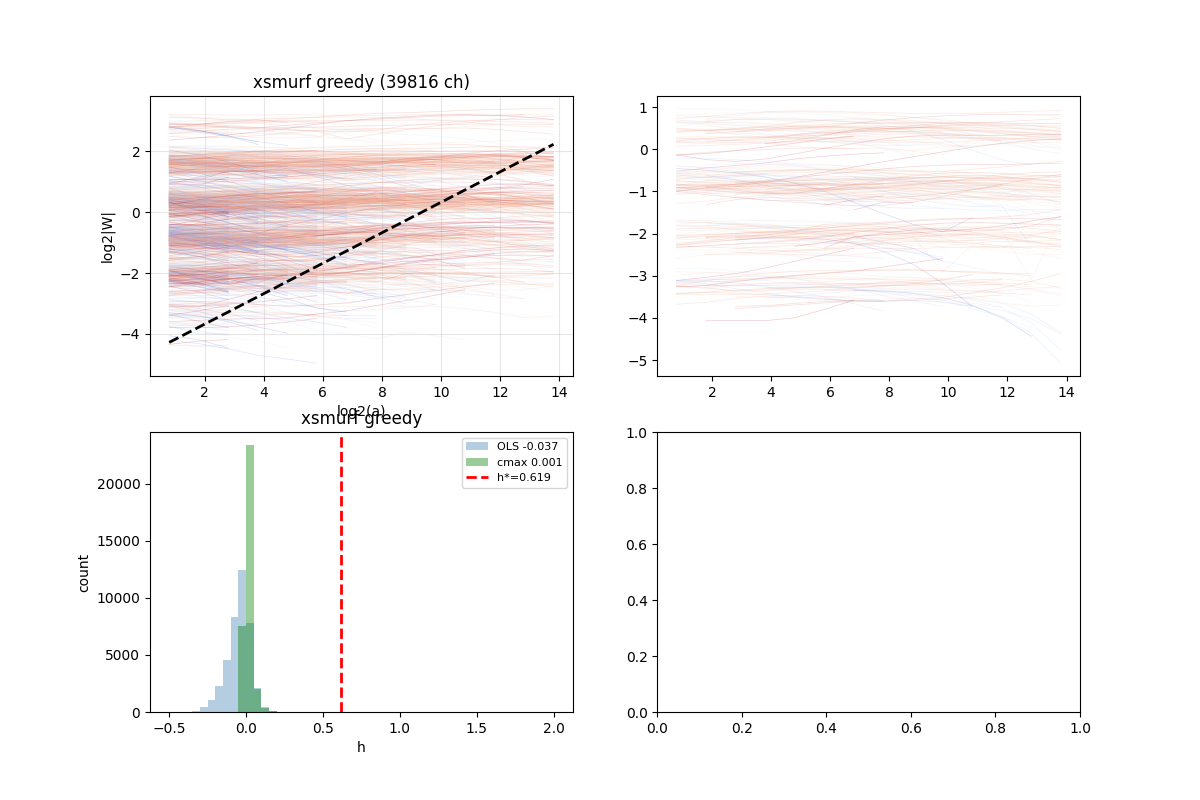

In [103]:
# Run anchor vs greedy on 1024 cascade

print('Anchor DP...')
chains_anc = anchor_chain(ext_imgs_diag, sc, anchor_idx=anchor_idx,
                                 dist_frac=0.3)
print(f'  {len(chains_anc)} chains')

print('xsmurf greedy NMS...')
ext_greedy = []
for i, scale in enumerate(sc):
    ext, _, _ = xsm.wtmm2d(
        xsm.XImage.from_numpy(cwt_1024['dx'][i]),
        xsm.XImage.from_numpy(cwt_1024['dy'][i]), scale, thresh=1e-3)
    ext_greedy.append(ext)
for i in range(len(sc)):
    ext_greedy[i] = xsm.cut_edge(ext_greedy[i], border_percent=25.0)
xsm.chain(ext_greedy, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
          similitude=0.8, smooth=False, verbose=False)
chains_greedy = xsm.extract_vertical_chains(ext_greedy, sc)
print(f'  {len(chains_greedy)} chains')

# Side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
log2_s = np.log2(sc)

for col, (label, chains) in enumerate([('xsmurf greedy', chains_greedy),
                                        ('DP anchor', chains_anc)]):
    h_lookup = {(int(h['x']), int(h['y'])): h['h']
                for h in xsm.compute_holder_exponents(chains)}
    h_vals = list(h_lookup.values())
    h_cmax = [h['h'] for h in compute_holder_chainmax(chains)]

    ax = axes[0, col]
    if h_vals:
        vmin, vmax = np.percentile(h_vals, [5, 95])
        cm = plt.cm.coolwarm
        nm = plt.Normalize(vmin, vmax)
        for ch in chains[:1500]:
            n = len(ch['mod'])
            if n < 3: continue
            h = h_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan)
            if not np.isfinite(h): continue
            ax.plot(ch['log2_scales'], ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid_scales = [ch['log2_mod'][len(ch['mod'])//2] for ch in chains
                      if len(ch['mod']) > len(sc)//2]
        if mid_scales:
            mid = len(log2_s) // 2
            ref = H_STAR * (log2_s - log2_s[mid]) + np.median(mid_scales)
            ax.plot(log2_s, ref, 'k--', lw=2)
    ax.set(xlabel='log2(a)', ylabel='log2|W|', title=f'{label} ({len(chains)} ch)')
    ax.grid(True, alpha=0.3)

    ax = axes[1, col]
    if h_vals:
        ax.hist(h_vals, bins=50, range=(-0.5, 2.0), alpha=0.4,
                label=f'OLS {np.median(h_vals):.3f}', color='steelblue')
    if h_cmax:
        ax.hist(h_cmax, bins=50, range=(-0.5, 2.0), alpha=0.4,
                label=f'cmax {np.median(h_cmax):.3f}', color='green')
    pk_h = 0.619  # theory peak
    ax.axvline(pk_h, color='red', ls='--', lw=2, label=f'h*={pk_h:.3f}')
    ax.set(xlabel='h', ylabel='count', title=label)
    ax.legend(fontsize=8)

plt.suptitle(f'CWT 1024->center512: greedy vs anchor (p={P_CASCADE}, H*={H_STAR})', fontsize=11)
plt.tight_layout()
plt.show()

# Chain length comparison
len_g = [len(ch['mod']) for ch in chains_greedy]
len_m = [len(ch['mod']) for ch in chains_anc]
print(f'Greedy: {len(chains_greedy)} chains, median length {np.median(len_g):.0f}')
print(f'Anchor: {len(chains_anc)} chains, median length {np.median(len_m):.0f}')

In [ ]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

# Build PFs
anc_pf = {}
for label, chains in [('greedy', chains_greedy), ('anchor', chains_anc)]:
    chains_pr = prune_chains(chains)
    hd_std_all, hd_cmax_all, _ = build_hd_from_chains(chains, sc)
    hd_std_pr, hd_cmax_pr, _ = build_hd_from_chains(chains_pr, sc)
    anc_pf[label] = {
        'all':    {'hd_std': hd_std_all, 'hd_cmax': hd_cmax_all, 'chains': chains},
        'pruned': {'hd_std': hd_std_pr,  'hd_cmax': hd_cmax_pr,  'chains': chains_pr},
        'scales': sc,
    }
    print(f'{label}: {len(chains)} -> {len(chains_pr)} pruned')

anc_state = {'scale_min': None, 'scale_max': None}
anc_dd = widgets.Dropdown(options=list(anc_pf.keys()), description='Chain:',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='240px'))
anc_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')
anc_pr = widgets.ToggleButtons(options=['All', 'Pruned'], value='All', description='Filter:')

q_show_anc = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4])
colors_q_anc = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_anc)))
_fig_anc, _axes_anc = plt.subplots(2, 3, figsize=(14, 7), gridspec_kw={'height_ratios': [1, 1]})
_axes_anc_top = _axes_anc[0]
_ax_anc_tau = _axes_anc[1, 0]
_ax_anc_dh = _axes_anc[1, 1]
_ax_anc_hist = _axes_anc[1, 2]
_anc_twin = [None]

def _anc_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_anc_top: return
    a = 2 ** event.xdata
    if event.button == 1: anc_state['scale_min'] = a
    elif event.button == 3: anc_state['scale_max'] = a
    if (anc_state['scale_min'] is not None and anc_state['scale_max'] is not None
            and anc_state['scale_min'] > anc_state['scale_max']):
        anc_state['scale_min'], anc_state['scale_max'] = anc_state['scale_max'], anc_state['scale_min']
    anc_draw()
_fig_anc.canvas.mpl_connect('button_press_event', _anc_click)

def anc_draw(*_):
    v = anc_pf[anc_dd.value]
    filt = 'pruned' if 'Pruned' in anc_pr.value else 'all'
    sub = v[filt]
    hd = sub['hd_std'] if 'Standard' in anc_cmax.value else sub['hd_cmax']
    scales_arr = np.array(v['scales'])
    log2_s = hd['log2_scales']
    chains = sub['chains']
    mode = f'{anc_cmax.value} {filt} ({len(chains)} ch)'

    if anc_state['scale_min'] is None: anc_state['scale_min'] = scales_arr[2]
    if anc_state['scale_max'] is None: anc_state['scale_max'] = scales_arr[-3]
    smin, smax = anc_state['scale_min'], anc_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_anc_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_anc_top[panel]
        for qi_val, color in zip(q_show_anc, colors_q_anc):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]; valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    ax.plot(log2_s[valid], sl*log2_s[valid]+ic, '-', color=color, lw=1.2, alpha=0.5)
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
    _axes_anc_top[1].set_title(f'{anc_dd.value} {mode} [{smin:.0f},{smax:.0f}]', fontsize=8)

    _ax_anc_tau.cla()
    if _anc_twin[0] is not None: _anc_twin[0].remove(); _anc_twin[0] = None
    _ax_anc_dh.cla()
    _ax_anc_hist.cla()

    q_th = np.linspace(-5, 5, 200)
    tau_th = tau_theory(q_th, P_CASCADE, H_STAR)
    h_th, D_th = hD_theory(q_th, P_CASCADE, H_STAR)

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])
        if valid.any():
            _ax_anc_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='measured')
            _ax_anc_tau.plot(q_th, tau_th, 'r--', lw=1.5, alpha=0.7, label='theory')
            _ax_anc_tau.set(xlabel='q', ylabel='tau(q)'); _ax_anc_tau.grid(True, alpha=0.2)
            ax2 = _ax_anc_tau.twinx(); _anc_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.plot(q_th, h_th, 'orange', ls='--', lw=1.5, alpha=0.7, label='h theory')
            ax2.set(ylabel='h(q)')
            l1, lb1 = _ax_anc_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_anc_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=6)

            _ax_anc_dh.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                              s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_anc_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_anc_dh.plot(h_th, D_th, 'r-', lw=2, alpha=0.7, label='theory', zorder=4)
            _ax_anc_dh.axhline(2, color='gray', ls='--', alpha=0.4)
            _ax_anc_dh.set(xlabel='h', ylabel='D(h)', title='D(h) vs theory',
                         xlim=(-0.5, 2.0), ylim=(0, 2.5))
            _ax_anc_dh.legend(fontsize=7); _ax_anc_dh.grid(True, alpha=0.2)

    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols: _ax_anc_hist.hist(h_ols, bins=50, range=(-0.5, 2.0), alpha=0.4, label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v: _ax_anc_hist.hist(h_cmax_v, bins=50, range=(-0.5, 2.0), alpha=0.4, label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    _ax_anc_hist.axvline(h_th[np.argmax(D_th)], color='red', ls='--', lw=2)
    _ax_anc_hist.set(xlabel='h', ylabel='count', title='Holders')
    _ax_anc_hist.legend(fontsize=7)
    _fig_anc.suptitle(f'Anchor: p={P_CASCADE} H*={H_STAR}', fontsize=11)
    _fig_anc.canvas.draw_idle()

anc_dd.observe(anc_draw, names='value')
anc_cmax.observe(anc_draw, names='value')
anc_pr.observe(anc_draw, names='value')
print('LEFT-click = min scale | RIGHT-click = max scale')
display(widgets.VBox([widgets.HBox([anc_dd, anc_cmax]), anc_pr]))
anc_draw()

## Hénon attractor: natural measure as multifractal image

Hénon map: $x_{n+1} = 1 - ax_n^2 + y_n$, $y_{n+1} = bx_n$ with $a=1.4$, $b=0.3$.

Iterate many times, bin into 2D histogram → natural measure.
Known: $D_0 \approx 1.26$, $D_1 \approx 1.26$, $D_2 \approx 1.22$.

Iterating Henon map 50,000,000 times...
  x: [-1.2847, 1.2730], y: [-0.3854, 0.3819]


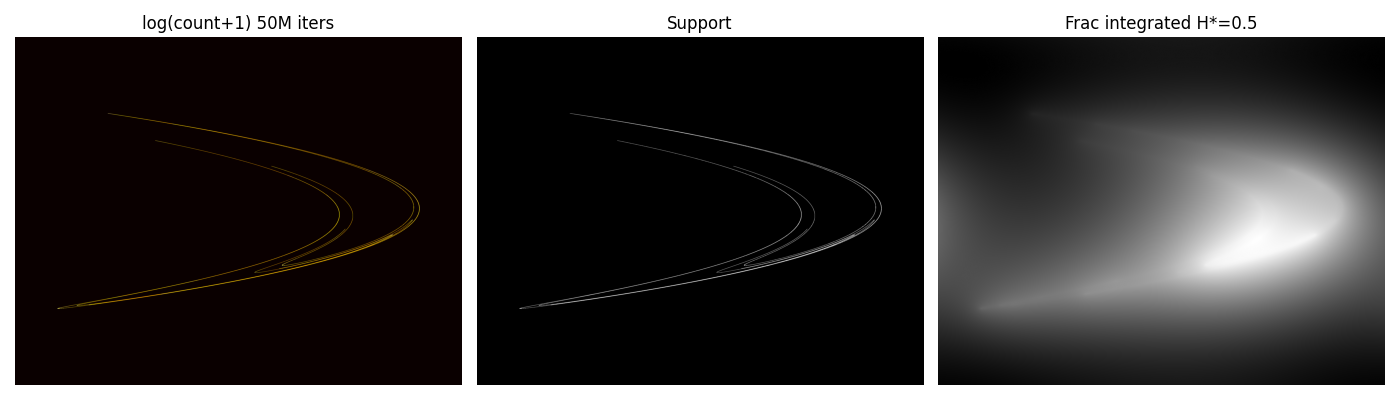

Occupied: 21145/4194304 = 0.5%


In [91]:
from numba import njit

@njit(cache=True)
def henon_iterate(n_iter, a=1.4, b=0.3, x0=0.0, y0=0.0, transient=10000):
    x, y = x0, y0
    for _ in range(transient):
        x_new = 1.0 - a * x * x + y
        y_new = b * x
        x, y = x_new, y_new
    xs = np.empty(n_iter, dtype=np.float64)
    ys = np.empty(n_iter, dtype=np.float64)
    for i in range(n_iter):
        x_new = 1.0 - a * x * x + y
        y_new = b * x
        x, y = x_new, y_new
        xs[i] = x
        ys[i] = y
    return xs, ys

N_ITER = 50_000_000
print(f'Iterating Henon map {N_ITER:,} times...')
xs, ys = henon_iterate(N_ITER)
print(f'  x: [{xs.min():.4f}, {xs.max():.4f}], y: [{ys.min():.4f}, {ys.max():.4f}]')

IMG_SIZE = 2048
margin = 0.3
henon_hist, _, _ = np.histogram2d(
    xs, ys, bins=IMG_SIZE,
    range=[[xs.min()-margin, xs.max()+margin], [ys.min()-margin, ys.max()+margin]])
henon_hist = henon_hist.T.astype(np.float64)

henon_log = np.log(henon_hist + 1).astype(np.float32)
henon_fint = fractional_integrate_2d(henon_hist.astype(np.float32), 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(np.log(henon_hist + 1), cmap='hot', aspect='auto')
axes[0].set_title(f'log(count+1) {N_ITER/1e6:.0f}M iters')
axes[1].imshow(henon_hist > 0, cmap='gray', aspect='auto')
axes[1].set_title('Support')
axes[2].imshow(henon_fint, cmap='gray', aspect='auto')
axes[2].set_title('Frac integrated H*=0.5')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print(f'Occupied: {(henon_hist>0).sum()}/{IMG_SIZE**2} = {(henon_hist>0).sum()/IMG_SIZE**2:.1%}')

In [104]:
# WTMM on Henon
n_oct=12
n_vox = 7

henon_variants = [('log(count+1)', henon_log), ('frac int H*=0.5', henon_fint)]
henon_results = {}
sc = compute_scales(n_oct, n_vox, a_min)

for label, img in henon_variants:
    print(f'--- {label} ---')
    cwt = cwt_2d_padmode(img, sc, pad=0, wavelet='mexican')
    ext_imgs = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_imgs.append(ext)
    for i in range(len(sc)):
        ext_imgs[i] = xsm.cut_edge(ext_imgs[i], border_percent=5)
    xsm.chain(ext_imgs, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              similitude=0.8, smooth=False, verbose=False)
    chains = xsm.extract_vertical_chains(ext_imgs, sc)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax = [h['h'] for h in compute_holder_chainmax(chains)]
    henon_results[label] = {'chains': chains, 'scales': sc, 'h_ols': h_ols, 'h_cmax': h_cmax}
    if h_ols:
        print(f'  {len(chains)} chains, OLS med={np.median(h_ols):.3f}, cmax med={np.median(h_cmax):.3f}')
print('Done.')

--- log(count+1) ---
  30796 chains, OLS med=-0.032, cmax med=0.266
--- frac int H*=0.5 ---
  75258 chains, OLS med=0.404, cmax med=0.395
Done.


log(count+1): 30796 -> 27091 pruned
frac int H*=0.5: 75258 -> 64657 pruned
LEFT-click = min | RIGHT-click = max


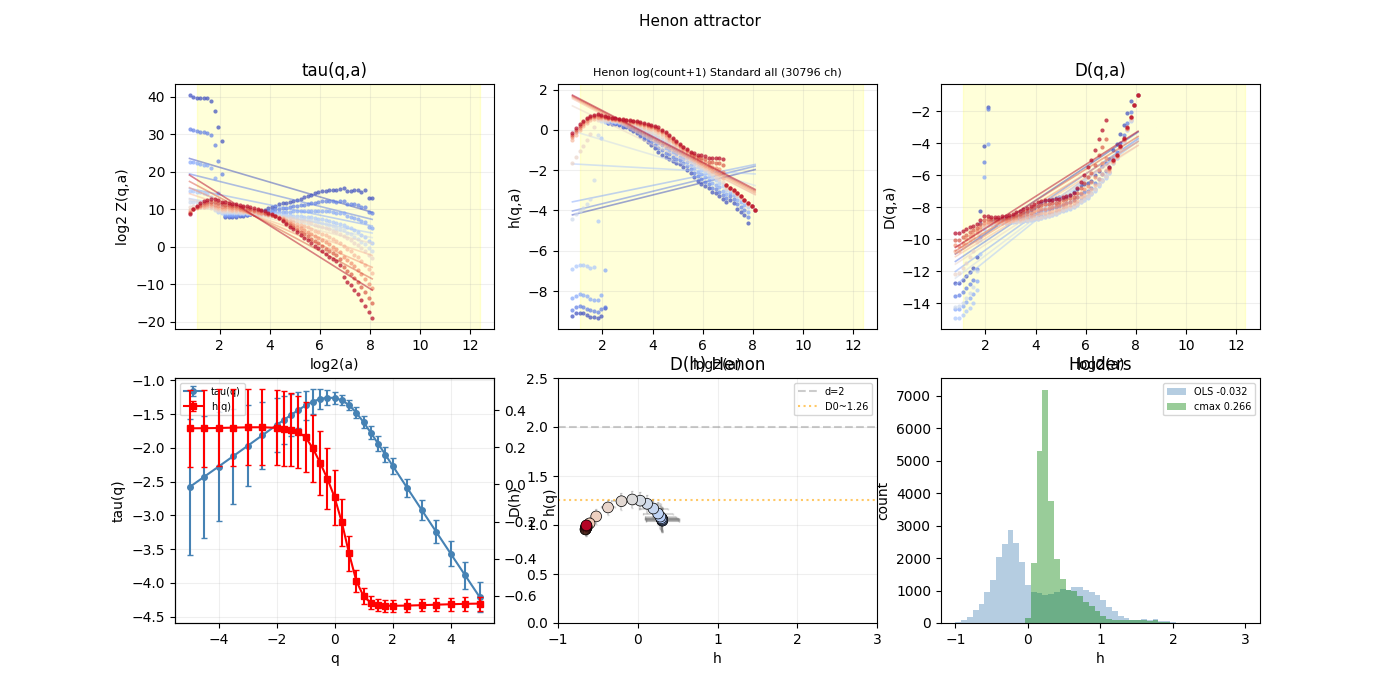

In [105]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

henon_pf = {}
for label in henon_results:
    chains = henon_results[label]['chains']
    chains_pr = prune_chains(chains)
    hd_std, hd_cmax, _ = build_hd_from_chains(chains, sc)
    hd_std_pr, hd_cmax_pr, _ = build_hd_from_chains(chains_pr, sc)
    henon_pf[label] = {
        'all':    {'hd_std': hd_std, 'hd_cmax': hd_cmax, 'chains': chains},
        'pruned': {'hd_std': hd_std_pr, 'hd_cmax': hd_cmax_pr, 'chains': chains_pr},
        'scales': sc,
    }
    print(f'{label}: {len(chains)} -> {len(chains_pr)} pruned')

hn_state = {'scale_min': None, 'scale_max': None}
hn_dd = widgets.Dropdown(options=list(henon_pf.keys()), description='Signal:',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='280px'))
hn_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')
hn_pr = widgets.ToggleButtons(options=['All', 'Pruned'], value='All', description='Filter:')

q_show_hn = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4, 10])
colors_q_hn = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_hn)))
_fig_hn, _axes_hn = plt.subplots(2, 3, figsize=(14, 7), gridspec_kw={'height_ratios': [1, 1]})
_axes_hn_top = _axes_hn[0]
_ax_hn_tau = _axes_hn[1, 0]; _ax_hn_dh = _axes_hn[1, 1]; _ax_hn_hist = _axes_hn[1, 2]
_hn_twin = [None]

def _hn_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_hn_top: return
    a = 2 ** event.xdata
    if event.button == 1: hn_state['scale_min'] = a
    elif event.button == 3: hn_state['scale_max'] = a
    if (hn_state['scale_min'] is not None and hn_state['scale_max'] is not None
            and hn_state['scale_min'] > hn_state['scale_max']):
        hn_state['scale_min'], hn_state['scale_max'] = hn_state['scale_max'], hn_state['scale_min']
    hn_draw()
_fig_hn.canvas.mpl_connect('button_press_event', _hn_click)

def hn_draw(*_):
    v = henon_pf[hn_dd.value]
    filt = 'pruned' if 'Pruned' in hn_pr.value else 'all'
    sub = v[filt]
    hd = sub['hd_std'] if 'Standard' in hn_cmax.value else sub['hd_cmax']
    scales_arr = np.array(v['scales']); log2_s = hd['log2_scales']; chains = sub['chains']
    mode = f'{hn_cmax.value} {filt} ({len(chains)} ch)'
    if hn_state['scale_min'] is None: hn_state['scale_min'] = scales_arr[2]
    if hn_state['scale_max'] is None: hn_state['scale_max'] = scales_arr[-3]
    smin, smax = hn_state['scale_min'], hn_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)
    for ax in _axes_hn_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_hn_top[panel]
        for qi_val, color in zip(q_show_hn, colors_q_hn):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]; valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    ax.plot(log2_s[valid], sl*log2_s[valid]+ic, '-', color=color, lw=1.2, alpha=0.5)
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title); ax.grid(True, alpha=0.2)
    _axes_hn_top[1].set_title(f'Henon {hn_dd.value} {mode}', fontsize=8)
    _ax_hn_tau.cla()
    if _hn_twin[0] is not None: _hn_twin[0].remove(); _hn_twin[0] = None
    _ax_hn_dh.cla(); _ax_hn_hist.cla()
    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])
        if valid.any():
            _ax_hn_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
            _ax_hn_tau.set(xlabel='q', ylabel='tau(q)'); _ax_hn_tau.grid(True, alpha=0.2)
            ax2 = _ax_hn_tau.twinx(); _hn_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.set(ylabel='h(q)')
            l1, lb1 = _ax_hn_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_hn_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)
            _ax_hn_dh.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                              s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_hn_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_hn_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
            _ax_hn_dh.axhline(1.26, color='orange', ls=':', alpha=0.6, label='D0~1.26')
            _ax_hn_dh.set(xlabel='h', ylabel='D(h)', title='D(h) Henon',
                         xlim=(-1, 3), ylim=(0, 2.5))
            _ax_hn_dh.legend(fontsize=7); _ax_hn_dh.grid(True, alpha=0.2)
    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols: _ax_hn_hist.hist(h_ols, bins=50, range=(-1, 3), alpha=0.4, label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v: _ax_hn_hist.hist(h_cmax_v, bins=50, range=(-1, 3), alpha=0.4, label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    _ax_hn_hist.set(xlabel='h', ylabel='count', title='Holders'); _ax_hn_hist.legend(fontsize=7)
    _fig_hn.suptitle('Henon attractor', fontsize=11)
    _fig_hn.canvas.draw_idle()

hn_dd.observe(hn_draw, names='value')
hn_cmax.observe(hn_draw, names='value')
hn_pr.observe(hn_draw, names='value')
print('LEFT-click = min | RIGHT-click = max')
display(widgets.VBox([widgets.HBox([hn_dd, hn_cmax]), hn_pr]))
hn_draw()

## Hénon: greedy vs anchor chaining on raw counts + frac integrated

In [108]:
# Greedy vs anchor on both Henon representations

henon_images = [
    ('raw counts', henon_hist.astype(np.float32)),
    ('log(count+1)', henon_log),
    ('frac int H*=0.5', henon_fint),
]
a_min=3
n_oct=14
n_vox=20
sc = compute_scales(n_oct, n_vox, a_min)
henon_compare = {}

for img_label, img in henon_images:
    print(f'\n=== {img_label} ===')
    cwt = cwt_2d_padmode(img, sc, pad=0, wavelet='gaussian')

    # --- Greedy NMS ---
    print('  Greedy...')
    ext_g = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-3)
        ext_g.append(ext)
    for i in range(len(sc)):
        ext_g[i] = xsm.cut_edge(ext_g[i], border_percent=5)
    xsm.chain(ext_g, a_min=a_min, n_oct=n_oct, n_vox=n_vox,
              similitude=0.8, smooth=False, verbose=False)
    chains_g = xsm.extract_vertical_chains(ext_g, sc)

    # --- Anchor ---
    print('  Anchor...')
    ext_a = []
    for i, scale in enumerate(sc):
        ext, _, _ = xsm.wtmm2d(
            xsm.XImage.from_numpy(cwt['dx'][i]),
            xsm.XImage.from_numpy(cwt['dy'][i]), scale, thresh=1e-1)
        ext_a.append(ext)
    for i in range(len(sc)):
        ext_a[i] = xsm.cut_edge(ext_a[i], border_percent=0)
        xsm.hsearch(ext_a[i])
        xsm.ssm(ext_a[i])
    chains_a = anchor_chain(ext_a, sc, dist_frac=0.2)

    for method_label, chains in [('greedy', chains_g), ('anchor', chains_a)]:
        key = f'{img_label} | {method_label}'
        h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
        h_cmax = [h['h'] for h in compute_holder_chainmax(chains)]
        henon_compare[key] = {'chains': chains, 'h_ols': h_ols, 'h_cmax': h_cmax}
        if h_ols:
            print(f'  {method_label}: {len(chains)} ch, OLS med={np.median(h_ols):.3f}, cmax med={np.median(h_cmax):.3f}')

print('\nDone.')


=== raw counts ===
  Greedy...
  Anchor...
  greedy: 2326 ch, OLS med=-0.979, cmax med=-0.000

=== log(count+1) ===
  Greedy...
  Anchor...
  greedy: 3126 ch, OLS med=-0.978, cmax med=0.000

=== frac int H*=0.5 ===
  Greedy...
  Anchor...
  greedy: 96 ch, OLS med=0.957, cmax med=0.955

Done.


raw counts | greedy: 2326 -> 21 pruned
raw counts | anchor: 0 -> 0 pruned
log(count+1) | greedy: 3126 -> 68 pruned
log(count+1) | anchor: 0 -> 0 pruned
frac int H*=0.5 | greedy: 96 -> 85 pruned
frac int H*=0.5 | anchor: 0 -> 0 pruned
LEFT-click = min | RIGHT-click = max


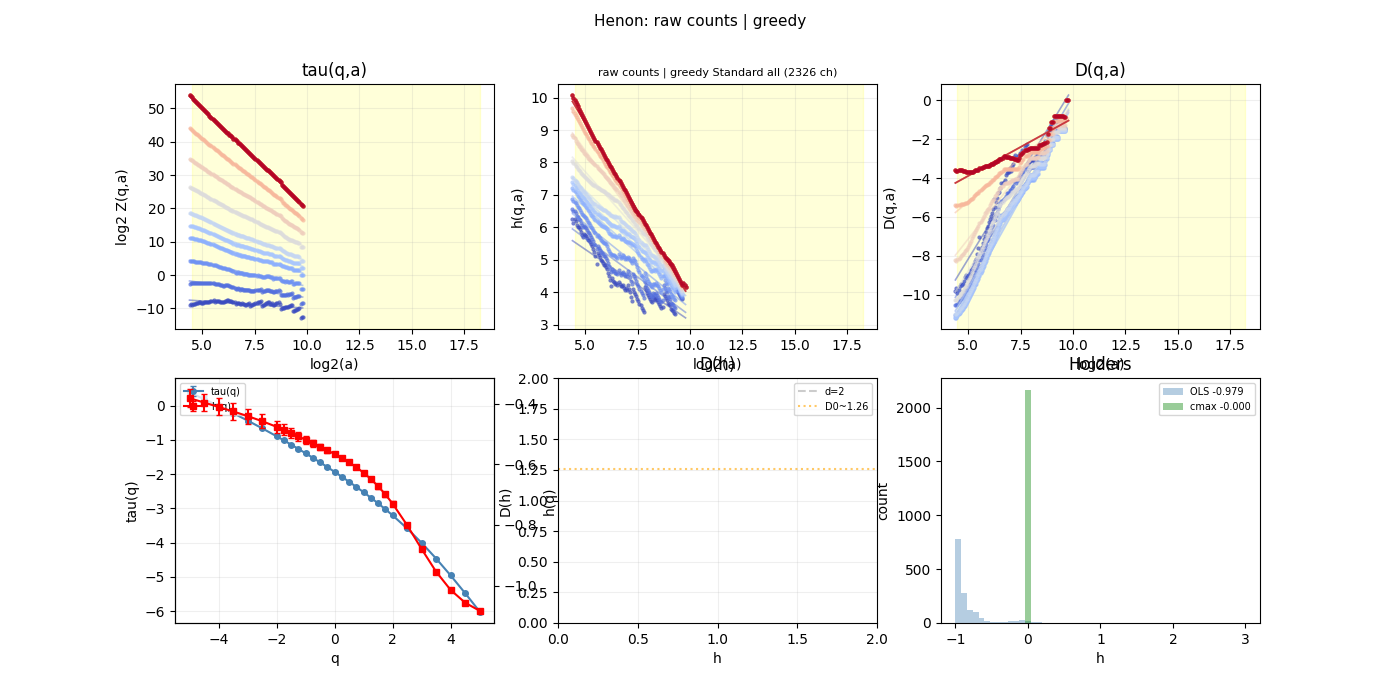

In [109]:
%matplotlib widget
from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus

hc_pf = {}
for key in henon_compare:
    chains = henon_compare[key]['chains']
    chains_pr = prune_chains(chains)
    hd_std, hd_cmax, _ = build_hd_from_chains(chains, sc)
    hd_std_pr, hd_cmax_pr, _ = build_hd_from_chains(chains_pr, sc)
    hc_pf[key] = {
        'all':    {'hd_std': hd_std, 'hd_cmax': hd_cmax, 'chains': chains},
        'pruned': {'hd_std': hd_std_pr, 'hd_cmax': hd_cmax_pr, 'chains': chains_pr},
        'scales': sc,
    }
    print(f'{key}: {len(chains)} -> {len(chains_pr)} pruned')

hc_state = {'scale_min': None, 'scale_max': None}
hc_dd = widgets.Dropdown(options=list(hc_pf.keys()), description='Variant:',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='360px'))
hc_cmax = widgets.ToggleButtons(options=['Standard', 'Chainmax'], value='Standard', description='PF:')
hc_pr = widgets.ToggleButtons(options=['All', 'Pruned'], value='All', description='Filter:')

q_show_hc = np.array([-3, -2, -1, 0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8])
colors_q_hc = plt.cm.coolwarm(np.linspace(0, 1, len(q_show_hc)))
_fig_hc, _axes_hc = plt.subplots(2, 3, figsize=(14, 7), gridspec_kw={'height_ratios': [1, 1]})
_axes_hc_top = _axes_hc[0]
_ax_hc_tau = _axes_hc[1, 0]; _ax_hc_dh = _axes_hc[1, 1]; _ax_hc_hist = _axes_hc[1, 2]
_hc_twin = [None]

def _hc_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in _axes_hc_top: return
    a = 2 ** event.xdata
    if event.button == 1: hc_state['scale_min'] = a
    elif event.button == 3: hc_state['scale_max'] = a
    if (hc_state['scale_min'] is not None and hc_state['scale_max'] is not None
            and hc_state['scale_min'] > hc_state['scale_max']):
        hc_state['scale_min'], hc_state['scale_max'] = hc_state['scale_max'], hc_state['scale_min']
    hc_draw()
_fig_hc.canvas.mpl_connect('button_press_event', _hc_click)

def hc_draw(*_):
    v = hc_pf[hc_dd.value]
    filt = 'pruned' if 'Pruned' in hc_pr.value else 'all'
    sub = v[filt]
    hd = sub['hd_std'] if 'Standard' in hc_cmax.value else sub['hd_cmax']
    scales_arr = np.array(v['scales']); log2_s = hd['log2_scales']; chains = sub['chains']
    mode = f'{hc_cmax.value} {filt} ({len(chains)} ch)'
    if hc_state['scale_min'] is None: hc_state['scale_min'] = scales_arr[2]
    if hc_state['scale_max'] is None: hc_state['scale_max'] = scales_arr[-3]
    smin, smax = hc_state['scale_min'], hc_state['scale_max']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    for ax in _axes_hc_top: ax.cla()
    for panel, (key, ylabel, title) in enumerate([
            ('tau_qa', 'log2 Z(q,a)', 'tau(q,a)'),
            ('h_qa', 'h(q,a)', 'h(q,a)'),
            ('D_qa', 'D(q,a)', 'D(q,a)')]):
        ax = _axes_hc_top[panel]
        for qi_val, color in zip(q_show_hc, colors_q_hc):
            idx = np.argmin(np.abs(hd['q_list'] - qi_val))
            y = hd[key][idx]; valid = np.isfinite(y)
            if valid.sum() < 2: continue
            ax.plot(log2_s[valid], y[valid], 'o', color=color, ms=3, alpha=0.7, mec='none')
            yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                try:
                    sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                    ax.plot(log2_s[valid], sl*log2_s[valid]+ic, '-', color=color, lw=1.2, alpha=0.5)
                except: pass
        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
        ax.set(xlabel='log2(a)', ylabel=ylabel, title=title); ax.grid(True, alpha=0.2)
    _axes_hc_top[1].set_title(f'{hc_dd.value} {mode}', fontsize=8)

    _ax_hc_tau.cla()
    if _hc_twin[0] is not None: _hc_twin[0].remove(); _hc_twin[0] = None
    _ax_hc_dh.cla(); _ax_hc_hist.cla()

    if s_mask.sum() >= 2:
        res = extract_hq_Dq_from_plateaus(hd, scale_range=(smin, smax))
        q = res['q_list']
        valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])
        if valid.any():
            _ax_hc_tau.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                               fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label='tau(q)')
            _ax_hc_tau.set(xlabel='q', ylabel='tau(q)'); _ax_hc_tau.grid(True, alpha=0.2)
            ax2 = _ax_hc_tau.twinx(); _hc_twin[0] = ax2
            ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                         fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label='h(q)')
            ax2.set(ylabel='h(q)')
            l1, lb1 = _ax_hc_tau.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            _ax_hc_tau.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=7)

            _ax_hc_dh.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                              s=60, edgecolors='black', linewidths=0.5, zorder=5)
            _ax_hc_dh.errorbar(res['h'][valid], res['D'][valid],
                            xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                            fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
            _ax_hc_dh.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
            _ax_hc_dh.axhline(1.26, color='orange', ls=':', alpha=0.6, label='D0~1.26')
            _ax_hc_dh.set(xlabel='h', ylabel='D(h)', title='D(h)',
                         xlim=(-0, 2), ylim=(0, 2))
            _ax_hc_dh.legend(fontsize=7); _ax_hc_dh.grid(True, alpha=0.2)

    h_ols = [h['h'] for h in xsm.compute_holder_exponents(chains)]
    h_cmax_v = [h['h'] for h in compute_holder_chainmax(chains)]
    if h_ols: _ax_hc_hist.hist(h_ols, bins=50, range=(-1, 3), alpha=0.4, label=f'OLS {np.median(h_ols):.3f}', color='steelblue')
    if h_cmax_v: _ax_hc_hist.hist(h_cmax_v, bins=50, range=(-1, 3), alpha=0.4, label=f'cmax {np.median(h_cmax_v):.3f}', color='green')
    _ax_hc_hist.set(xlabel='h', ylabel='count', title='Holders'); _ax_hc_hist.legend(fontsize=7)
    _fig_hc.suptitle(f'Henon: {hc_dd.value}', fontsize=11)
    _fig_hc.canvas.draw_idle()

hc_dd.observe(hc_draw, names='value')
hc_cmax.observe(hc_draw, names='value')
hc_pr.observe(hc_draw, names='value')
print('LEFT-click = min | RIGHT-click = max')
display(widgets.VBox([widgets.HBox([hc_dd, hc_cmax]), hc_pr]))
hc_draw()